# CTU-UHB Step 2+3 Multiclass Short Experiment Plan


Minimal refactor of the CTU-UHB multiclass pipeline for a focused dissertation-ready experiment.


## Goal

Improve **step-level / record-step 3-class performance**, especially **Mild recall**, while keeping grouped cross-validation by `rec_id` and the existing preprocessing logic.


## Minimal changes in this version

- Drop **Step 1** entirely

- Train and evaluate on **Step 2 + Step 3** 30-minute windows only, using **3 controlled windows per step**

- Increase the window-quality threshold to **`max_nan_fraction = 0.16`**

- Keep the standard **3-class softmax** CNN as the primary model

- Add a compact **engineered-feature branch** alongside the raw-signal CNN branch

- Standardize engineered features using **training-fold statistics only**

- Keep **grouped CV by `rec_id`** but evaluate at the **record-step level** rather than collapsing back to one label per record


## 1. Imports

In [2]:
# ── Disable oneDNN/MKL ops BEFORE importing TF ──────────────────
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Core
import math
import numpy as np
import pandas as pd
from pathlib import Path
import ast
import wfdb
import json
import warnings
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

# Signal processing
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

# Try to import StratifiedGroupKFold (sklearn >= 1.0)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available — will use group-aware stratified splitting.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False
    print("WARNING: StratifiedGroupKFold not available (sklearn < 1.0).")
    print("         Falling back to GroupKFold — class balance across folds not guaranteed.")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, GlobalAveragePooling1D, Dense,
    Concatenate, Reshape, Multiply, Add,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
)
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

StratifiedGroupKFold available — will use group-aware stratified splitting.


c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False


## 2. Configuration

All experiment parameters in one place. Change values here to toggle between
from-scratch training and transfer learning, adjust segmentation, etc.

In [3]:
# ═══════════════════════════════════════════════════════════════════
# PATHS
# ═══════════════════════════════════════════════════════════════════

RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
PTBXL_PATH    = Path("../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3")  # legacy / optional
OUTPUT_DIR    = Path("outputs/step23_softmax_short_plan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
# SIGNAL PARAMETERS
# ═══════════════════════════════════════════════════════════════════

RAW_SAMPLING_RATE      = 4
TARGET_SAMPLING_RATE   = 1
DOWNSAMPLE_FACTOR      = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE

WINDOW_MINUTES  = 30
WINDOW_LENGTH   = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE

# Keep the existing key names to minimize downstream code changes.
SAMPLING_RATE   = TARGET_SAMPLING_RATE
SEGMENT_MINUTES = WINDOW_MINUTES
SEGMENT_LENGTH  = WINDOW_LENGTH

# ═══════════════════════════════════════════════════════════════════
# LABEL DEFINITIONS
# ═══════════════════════════════════════════════════════════════════

NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

# Legacy PTB-XL mapping retained for compatibility with older helper cells.
PTBXL_CLASS_NAMES = ["Normal", "Intermediate", "Pathological"]

# ═══════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION
# ═══════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Step-window experiment scope ──────────────────────────────
    step_numbers           = [2, 3],
    mode_a_offsets         = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes        = SEGMENT_MINUTES,
    segment_length         = SEGMENT_LENGTH,
    max_nan_fraction       = 0.16,
    pad_short_records      = False,

    # ── Cross-Validation ──────────────────────────────────────────
    n_splits               = 10 ,
    cv_seed                = 42,
    min_severe_records     = 10,
    max_cv_attempts        = 100,

    # ── Model Architecture ────────────────────────────────────────
    temporal_filters       = 32,
    temporal_kernel        = 7,
    separable_filters      = 32,
    separable_kernels      = [3, 7, 15],
    projection_filters     = 32,
    dropout_rate           = 0.40,

    # ── Engineered-feature branch ────────────────────────────────
    use_clinical_features  = True,

    # ── Legacy transfer settings kept but disabled ───────────────
    use_adaptation_layers  = False,
    adaptation_units       = [64, 32],
    adaptation_dropout     = 0.30,
    skip_ptbxl_pretrain    = True,

    # ── Record-level reweighting / calibration ───────────────────
    oversample_severe      = False,
    severe_boost           = 0.0,

    # ── Augmentation Pipeline ────────────────────────────────────
    augment_train          = True,
    aug_time_warp          = True,
    aug_warp_sigma         = 0.10,
    aug_amplitude_scale    = True,
    aug_amp_sigma          = 0.10,
    aug_noise              = True,
    aug_noise_std          = 0.02,
    aug_signal_loss        = True,
    aug_gap_frac           = 0.05,
    aug_n_gaps             = 2,

    # ── Training: softmax baseline first ────────────────────────
    scratch_epochs         = 100,
    scratch_lr             = 1e-3,
    scratch_batch          = 16,
    scratch_patience       = 20,
    label_smoothing        = 0.05,
    use_class_weights      = True,

    # ── Legacy transfer hyperparameters retained for compatibility ─
    s0_epochs              = 15,
    s0_lr                  = 1e-3,
    s0_batch               = 64,
    s0_patience            = 5,
    s1a_epochs             = 30,
    s1a_lr                 = 1e-4,
    s1a_batch              = 16,
    s1a_patience           = 10,
    s1b_epochs             = 40,
    s1b_lr                 = 5e-5,
    s1b_batch              = 8,
    s1b_patience           = 15,
    s1b_unfreeze_blocks    = 3,
    s1c_epochs             = 50,
    s1c_lr                 = 1e-5,
    s1c_batch              = 8,
    s1c_patience           = 20,
    warmup_epochs          = 5,
    warmup_start_lr        = 1e-6,
    s1a_augment            = False,
    s1b_augment            = True,
    s1b_noise_std          = 0.01,
    s1c_augment            = True,
    s1c_noise_std          = 0.02,
)

windows_per_step = {step_num: len(offsets) for step_num, offsets in CFG['controlled_step_offsets'].items()}
if len(set(windows_per_step.values())) != 1:
    raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))

print("═" * 60)
print("CONFIGURATION SUMMARY")
print("═" * 60)
print(f"  Windows used:      Steps {CFG['step_numbers']}")
print(f"  Sampling rate:     {RAW_SAMPLING_RATE} Hz raw -> {SAMPLING_RATE} Hz model input")
print(f"  Window length:     {CFG['segment_minutes']} min = {CFG['segment_length']} samples @ {SAMPLING_RATE} Hz")
print(f"  Canonical offsets: {CFG['mode_a_offsets']}")
print(f"  Controlled windows:{CONTROLLED_WINDOWS_PER_STEP} per step")
for step_num in CFG['step_numbers']:
    print(f"    Step {step_num}: {CFG['controlled_step_offsets'][step_num]}")
print(f"  Max NaN frac:      {CFG['max_nan_fraction']:.0%}")
print(f"  CV folds:          {CFG['n_splits']}")
print(f"  Min Severe/fold:   {CFG['min_severe_records']} records")
print(f"  Label smoothing:   {CFG['label_smoothing']:.2f}")
print(f"  Softmax baseline:  enabled")
print(f"  Feature branch:    compact engineered FHR features")
print(f"  Grouped CV:        by rec_id (unchanged)")
print(f"  PTB-XL legacy:     disabled in this short plan")
print("═" * 60)

════════════════════════════════════════════════════════════
CONFIGURATION SUMMARY
════════════════════════════════════════════════════════════
  Windows used:      Steps [2, 3]
  Sampling rate:     4 Hz raw -> 1 Hz model input
  Window length:     30 min = 1800 samples @ 1 Hz
  Canonical offsets: {2: (60, 30), 3: (30, 0)}
  Controlled windows:3 per step
    Step 2: [(70, 40), (60, 30), (50, 20)]
    Step 3: [(50, 20), (40, 10), (30, 0)]
  Max NaN frac:      16%
  CV folds:          10
  Min Severe/fold:   10 records
  Label smoothing:   0.05
  Softmax baseline:  enabled
  Feature branch:    compact engineered FHR features
  Grouped CV:        by rec_id (unchanged)
  PTB-XL legacy:     disabled in this short plan
════════════════════════════════════════════════════════════


## 4. Step-Window Extraction (Steps 2 + 3 Only)



**Strategy:**

- Extract only the **Step 2** and **Step 3** 30-minute delivery-anchored windows

- For each eligible record-step, create a fixed set of **3 controlled windows**

- Keep **grouping by `rec_id`** unchanged so all windows from one record stay in the same fold

- Reject the entire record-step if any controlled window is too short or exceeds the missing-data threshold

- Track `rec_id` and window metadata so validation predictions are still aggregated at the **record level**


In [4]:
# ═══════════════════════════════════════════════════════════════════

# DATA LOADING & FHR CLEANING

# ═══════════════════════════════════════════════════════════════════



def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:

    """Load Step 2 and Step 3 labels independently and filter uninterpretable rows."""

    step_labels = {}

    for step_num, path in step_paths.items():

        df = pd.read_csv(path)

        total = len(df)

        df = df[df['Majority_Vote_Label'] != -1].copy()

        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)

        df['rec_id'] = df['rec_id'].astype(str)

        excluded = total - len(df)

        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")

        for cls_id, name in enumerate(CLASS_NAMES):

            n = int((df['class_id'] == cls_id).sum())

            print(f"  Class {cls_id} ({name}): {n} ({n / max(len(df), 1) * 100:.1f}%)")

        step_labels[step_num] = df

    return step_labels





def remove_trailing_zeros(signal) -> list:

    """Remove trailing zeros (marks end of recording / delivery)."""

    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)

    i = len(sig) - 1

    while i >= 0 and sig[i] == 0:

        i -= 1

    return sig[:i + 1]





def clean_fhr(fhr_array, fs: int = 4) -> np.ndarray:

    """

    Clean a fetal heart rate signal using the existing pipeline.



    This refactor deliberately keeps preprocessing unchanged.

    """

    fhr = pd.Series(np.array(fhr_array, dtype=float))



    # Step 1: Replace 0 with NaN

    fhr.replace(0, np.nan, inplace=True)



    # Step 2: Remove NaN gaps > 15 consecutive seconds

    na = fhr.isnull()

    gap_groups = na.ne(na.shift()).cumsum()

    gap_sizes = fhr.groupby(gap_groups.values).transform('size')

    fhr = fhr[~(gap_sizes.ge(fs * 15 + 1) & na)].reset_index(drop=True)



    # Step 3: Outlier detection

    fhr[fhr < 50] = np.nan

    fhr[fhr > 200] = np.nan



    # Step 4: Linear interpolation

    fhr = fhr.interpolate(method='linear')



    # Step 5: Spike detection and removal

    diff = fhr - fhr.shift()

    fhr[(diff > 25) | (diff < -25)] = np.nan

    fhr = fhr.interpolate(method='linear')



    # Edge NaN fill

    fhr = fhr.ffill().bfill()



    return fhr.values





def downsample_signal(signal: np.ndarray, factor: int = 4) -> np.ndarray:

    """Downsample a cleaned 1D signal by simple decimation."""

    if factor <= 1:

        return np.asarray(signal, dtype=np.float32)

    return np.asarray(signal[::factor], dtype=np.float32)





def load_raw_signals(dataset_path: Path) -> Dict[str, dict]:

    """

    Load all CTU-UHB records, clean FHR at native 4 Hz, then downsample to 1 Hz.



    Returns

    -------

    dict[rec_id] = {'FHR': np.ndarray, 'length': int}

    """

    records = [p.stem for p in dataset_path.glob("*.hea")]

    print(f"Found {len(records)} .hea files in {dataset_path}")



    data = {}

    for rid in sorted(records):

        try:

            rec = wfdb.rdrecord(str(dataset_path / rid))

            fhr_raw = remove_trailing_zeros(rec.p_signal[:, 0].tolist())

            fhr_clean = clean_fhr(fhr_raw, fs=RAW_SAMPLING_RATE)

            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)

            data[rid] = {'FHR': fhr_downsampled, 'length': len(fhr_downsampled)}

        except Exception as e:

            print(f"  Skipping {rid}: {e}")



    print(f"\nLoaded {len(data)} FHR signals")

    lengths = [d['length'] for d in data.values()]

    print(f"  Duration range: {min(lengths)/(SAMPLING_RATE*60):.1f} – {max(lengths)/(SAMPLING_RATE*60):.1f} minutes")

    return data





# ── Load data ──

STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}

step_label_dfs = load_step_labels(STEP_LABEL_PATHS)

signal_data = load_raw_signals(RAW_DATASET)



labelled_rec_ids = set()

for df in step_label_dfs.values():

    labelled_rec_ids.update(df['rec_id'].tolist())



valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))

print(f"\nRecords with at least one Step 2/3 label and a signal: {len(valid_rec_ids)}")


Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ..\data\raw_dataset

Loaded 552 FHR signals
  Duration range: 33.8 – 90.1 minutes

Records with at least one Step 2/3 label and a signal: 549


## 4. Step-Window Construction at 1 Hz

**Strategy:**
- Clean raw FHR at its native **4 Hz**, then downsample to **1 Hz** for modeling.
- Extract a fixed set of **3 controlled 30-minute windows per eligible step** rather than a single canonical window.
- Step 2 uses earlier / canonical / later offsets around the canonical interval; Step 3 is delivery-bounded, so its three windows run from earlier coverage up to the canonical delivery window.
- If any of the 3 controlled windows for a record-step is too short or fails the missing-data threshold, that record-step is dropped entirely.
- The `group` array still tracks the parent `rec_id` for every window, so grouped CV remains leakage-free and validation windows are still aggregated back to the record level.

In [5]:
# ═══════════════════════════════════════════════════════════════════

# STEP-WINDOW EXTRACTION (STEPS 2 + 3 ONLY)

# ═══════════════════════════════════════════════════════════════════



def _window_bounds_from_end(

    sig_len: int,

    offsets_from_end_min: Tuple[int, int],

    fs: int = 4,

) -> Optional[Tuple[int, int]]:

    """Return sample bounds for one delivery-anchored window."""

    start_from_end_min, end_from_end_min = offsets_from_end_min

    if start_from_end_min <= end_from_end_min:

        raise ValueError(

            f"Expected start offset > end offset, got {offsets_from_end_min}"

        )



    start_from_end = start_from_end_min * 60 * fs

    end_from_end = end_from_end_min * 60 * fs



    if sig_len < start_from_end:

        return None



    start_idx = sig_len - start_from_end

    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len

    if end_idx <= start_idx:

        return None



    return int(start_idx), int(end_idx)





def _get_controlled_window_bounds(

    sig_len: int,

    step_num: int,

    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],

    fs: int = 4,

) -> Optional[List[Tuple[int, Tuple[int, int], int, int]]]:

    """Return all controlled window bounds for one record-step."""

    if step_num not in controlled_step_offsets:

        raise KeyError(f"Missing controlled offsets for step {step_num}")



    bounds = []

    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):

        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)

        if cur_bounds is None:

            return None

        start_idx, end_idx = cur_bounds

        bounds.append((window_index, offsets, start_idx, end_idx))



    return bounds





def create_step_windows(

    signal_data: Dict[str, dict],

    step_label_dfs: Dict[int, pd.DataFrame],

    record_ids: List[str],

    window_length: int = 7200,

    step_numbers: Optional[List[int]] = None,

    step_offsets: Optional[Dict[int, Tuple[int, int]]] = None,

    controlled_step_offsets: Optional[Dict[int, List[Tuple[int, int]]]] = None,

    max_nan_fraction: float = 0.16,

    pad_short_records: bool = False,

    fs: int = 4,

) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:

    """

    Extract controlled Step 2 and Step 3 30-minute windows from cleaned CTU-UHB FHR signals.



    Each eligible record-step contributes the same fixed number of windows. If any controlled

    window for a record-step is too short or exceeds the missing-data threshold, that entire

    record-step is dropped so records are not weighted inconsistently.

    """

    if step_numbers is None:

        step_numbers = [2, 3]

    if step_offsets is None:

        step_offsets = {2: (60, 30), 3: (30, 0)}

    if controlled_step_offsets is None:

        controlled_step_offsets = {

            step_num: [step_offsets[step_num]]

            for step_num in step_numbers

        }



    windows_per_step = {

        step_num: len(controlled_step_offsets[step_num])

        for step_num in step_numbers

    }

    if len(set(windows_per_step.values())) != 1:

        raise ValueError(

            f"All steps must use the same number of controlled windows, got: {windows_per_step}"

        )



    fixed_windows_per_step = next(iter(windows_per_step.values()))



    X_list = []

    y_list = []

    group_list = []

    meta_list = []



    accepted_record_steps = 0

    skipped_step_short = 0

    skipped_step_nan = 0



    for rid in record_ids:

        if rid not in signal_data:

            continue



        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)

        sig_len = len(fhr)



        for step_num in step_numbers:

            step_df = step_label_dfs.get(step_num)

            if step_df is None:

                continue



            row = step_df[step_df['rec_id'] == rid]

            if row.empty:

                continue



            controlled_bounds = _get_controlled_window_bounds(

                sig_len,

                step_num,

                controlled_step_offsets,

                fs=fs,

            )

            if controlled_bounds is None:

                skipped_step_short += 1

                continue



            label = int(row['class_id'].iloc[0])

            step_windows = []

            step_failed_short = False

            step_failed_nan = False



            for window_index, offsets, start_idx, end_idx in controlled_bounds:

                window = fhr[start_idx:end_idx]



                if len(window) < window_length:

                    if pad_short_records:

                        pad_len = window_length - len(window)

                        window = np.pad(window, (pad_len, 0), mode='edge')

                    else:

                        step_failed_short = True

                        break



                missing_frac_prefill = float(np.mean(np.isnan(window) | (window == 0)))

                if missing_frac_prefill > max_nan_fraction:

                    step_failed_nan = True

                    break



                if np.any(np.isnan(window)):

                    s = pd.Series(window)

                    window = s.interpolate(method='linear').ffill().bfill().values



                step_windows.append({

                    'window': window.astype(np.float32),

                    'window_index': window_index,

                    'offset_start_min': int(offsets[0]),

                    'offset_end_min': int(offsets[1]),

                    'window_start': start_idx,

                    'window_end': end_idx,

                    'missing_frac_prefill': missing_frac_prefill,

                })



            if step_failed_short:

                skipped_step_short += 1

                continue



            if step_failed_nan:

                skipped_step_nan += 1

                continue



            if len(step_windows) != fixed_windows_per_step:

                raise RuntimeError(

                    f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, "

                    f"got {len(step_windows)}"

                )



            accepted_record_steps += 1

            for step_window in step_windows:

                X_list.append(step_window['window'])

                y_list.append(label)

                group_list.append(rid)

                meta_list.append({

                    'rec_id': rid,

                    'step': step_num,

                    'window_index': step_window['window_index'],

                    'offset_start_min': step_window['offset_start_min'],

                    'offset_end_min': step_window['offset_end_min'],

                    'window_start': step_window['window_start'],

                    'window_end': step_window['window_end'],

                    'label': label,

                    'missing_frac_prefill': step_window['missing_frac_prefill'],

                })



    if X_list:

        X_windows = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]

    else:

        X_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.array(y_list, dtype=np.int32)

    groups = np.array(group_list)

    metadata = pd.DataFrame(meta_list)



    print("\nStep-window extraction complete:")

    print(f"  Total windows:             {len(X_windows)} from {len(set(group_list))} records")

    print(f"  Window shape:              {X_windows.shape}")

    print(f"  Controlled windows/step:   {fixed_windows_per_step}")

    print(f"  Accepted record-steps:     {accepted_record_steps}")

    print(f"  Skipped record-steps (short): {skipped_step_short}")

    print(f"  Skipped record-steps (NaN):   {skipped_step_nan}")

    if len(metadata) > 0:

        for step_num in step_numbers:

            step_mask = metadata['step'] == step_num

            n_step_windows = int(step_mask.sum())

            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())

            print(f"  Step {step_num}:               {n_step_windows} windows from {n_step_records} records")

        for cls_id, name in enumerate(CLASS_NAMES):

            n_class = int(np.sum(y_windows == cls_id))

            print(f"  Class {cls_id} ({name}):      {n_class} windows")



    return X_windows, y_windows, groups, metadata





# ── Create Step 2 + Step 3 windows from all valid records ──

print("Creating Step 2 + Step 3 controlled 30-minute windows...")

X_all, y_all, groups_all, meta_all = create_step_windows(

    signal_data=signal_data,

    step_label_dfs=step_label_dfs,

    record_ids=valid_rec_ids,

    window_length=CFG['segment_length'],

    step_numbers=CFG['step_numbers'],

    step_offsets=CFG['mode_a_offsets'],

    controlled_step_offsets=CFG['controlled_step_offsets'],

    max_nan_fraction=CFG['max_nan_fraction'],

    pad_short_records=CFG['pad_short_records'],

    fs=SAMPLING_RATE,

)



windows_per_record = pd.Series(groups_all).value_counts()

if len(windows_per_record) > 0:

    print(f"\nWindows per record: min={windows_per_record.min()}, max={windows_per_record.max()}, mean={windows_per_record.mean():.1f}")

    print("Step counts:")

    print(meta_all['step'].value_counts().sort_index())

    print("Window index counts:")

    print(meta_all['window_index'].value_counts().sort_index())

Creating Step 2 + Step 3 controlled 30-minute windows...

Step-window extraction complete:
  Total windows:             1398 from 336 records
  Window shape:              (1398, 1800, 1)
  Controlled windows/step:   3
  Accepted record-steps:     466
  Skipped record-steps (short): 419
  Skipped record-steps (NaN):   0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      564 windows
  Class 1 (Mild):      636 windows
  Class 2 (Severe):      198 windows

Windows per record: min=3, max=6, mean=4.2
Step counts:
step
2    399
3    999
Name: count, dtype: int64
Window index counts:
window_index
0    466
1    466
2    466
Name: count, dtype: int64


## 5. PTB-XL Pretraining Support (Optional)

**Domain bridge:** PTB-XL provides 12-lead ECG at 500 Hz. We derive instantaneous
heart rate HR(t) from R-R intervals and resample to **1 Hz** to match this CTU-UHB setup.

**3-class mapping:**
- NORM → 0 (Normal)
- STTC, CD → 1 (Intermediate)
- MI, HYP → 2 (Pathological)

**Sequence length handling:** PTB-XL HR sequences are much shorter than the
CTU-UHB 30-minute windows (**1800 samples at 1 Hz**). We interpolate/resize
PTB-XL signals to match the target window length so the same backbone accepts both.

In [6]:
# ═══════════════════════════════════════════════════════════════════
# PTB-XL PRETRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def load_ptbxl_metadata(ptbxl_path: Path) -> pd.DataFrame:
    """Load PTB-XL metadata and parse SCP codes."""
    db_path = ptbxl_path / "ptbxl_database.csv"
    df = pd.read_csv(db_path, index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
    print(f"PTB-XL: {len(df)} records, {df['patient_id'].nunique()} patients")
    return df


def load_scp_mapping(ptbxl_path: Path):
    """Load SCP statement → diagnostic superclass mapping."""
    scp_df = pd.read_csv(ptbxl_path / "scp_statements.csv", index_col=0)
    diag_df = scp_df[scp_df.diagnostic == 1.0].copy()
    return scp_df, diag_df


def map_to_superclass(scp_dict: dict, diag_df: pd.DataFrame) -> set:
    """Map SCP codes to diagnostic superclasses."""
    result = set()
    for code, likelihood in scp_dict.items():
        if code in diag_df.index and likelihood > 0:
            cls = diag_df.loc[code, 'diagnostic_class']
            if pd.notna(cls):
                result.add(cls)
    return result


def assign_ptbxl_3class(superclasses: set) -> int:
    """
    Map PTB-XL superclasses → 3 classes for transfer learning.

    Class 0 (Normal):       NORM only
    Class 1 (Intermediate): STTC and/or CD
    Class 2 (Pathological): MI and/or HYP (worst wins)
    Returns -1 if no diagnostic info.
    """
    if not superclasses:
        return -1
    if superclasses & {'MI', 'HYP'}:
        return 2
    if superclasses & {'STTC', 'CD'}:
        return 1
    if 'NORM' in superclasses:
        return 0
    return -1


def ecg_to_heart_rate(
    ecg_signal: np.ndarray,
    ecg_fs: int = 500,
    target_fs: int = SAMPLING_RATE,
) -> Optional[np.ndarray]:
    """
    Derive instantaneous heart rate from a single ECG lead.

    Steps:
    1. Detect R-peaks using scipy.signal.find_peaks
    2. Compute instantaneous HR from R-R intervals
    3. Interpolate to uniform time grid at target_fs

    Parameters
    ----------
    ecg_signal : np.ndarray
        Raw ECG signal from one lead.
    ecg_fs : int
        ECG sampling rate (500 Hz for PTB-XL).
    target_fs : int
        Target sampling rate for HR(t).

    Returns
    -------
    np.ndarray or None
        Heart rate time series at target_fs, or None if detection fails.
    """
    # R-peak detection — use Lead II (most prominent R-peaks)
    min_distance = int(0.3 * ecg_fs)  # minimum 300ms between beats
    peaks, _ = find_peaks(ecg_signal, distance=min_distance,
                          height=np.percentile(ecg_signal, 60))

    if len(peaks) < 3:
        return None  # Not enough peaks for HR estimation

    # RR intervals → instantaneous HR
    rr_intervals = np.diff(peaks) / ecg_fs  # seconds
    hr_values = 60.0 / rr_intervals  # bpm
    hr_times = (peaks[:-1] + peaks[1:]) / 2.0 / ecg_fs  # midpoint times

    # Filter physiological range (30–220 bpm)
    valid = (hr_values >= 30) & (hr_values <= 220)
    if valid.sum() < 2:
        return None
    hr_values = hr_values[valid]
    hr_times = hr_times[valid]

    # Interpolate to uniform grid at target_fs
    duration = len(ecg_signal) / ecg_fs
    n_samples = int(duration * target_fs)
    if n_samples < 2:
        return None
    t_uniform = np.linspace(hr_times[0], hr_times[-1], n_samples)
    interp_fn = interp1d(hr_times, hr_values, kind='linear',
                         fill_value='extrapolate')
    hr_resampled = interp_fn(t_uniform)

    # Clip to physiological range after interpolation
    hr_resampled = np.clip(hr_resampled, 30, 220)

    return hr_resampled.astype(np.float32)


def resize_signal(signal: np.ndarray, target_length: int) -> np.ndarray:
    """
    Resize a 1D signal to target_length using linear interpolation.

    Used to bring PTB-XL HR sequences to the same
    length as CTU-UHB windows so the backbone sees
    identical input shapes during both pretraining and fine-tuning.
    """
    if len(signal) == target_length:
        return signal
    x_old = np.linspace(0, 1, len(signal))
    x_new = np.linspace(0, 1, target_length)
    interp_fn = interp1d(x_old, signal, kind='linear')
    return interp_fn(x_new).astype(np.float32)


def load_ptbxl_hr_dataset(
    ptbxl_path: Path,
    target_length: int = SEGMENT_LENGTH,
    target_fs: int = SAMPLING_RATE,
    ecg_fs: int = 500,
    use_lead: int = 1,  # Lead II (0-indexed)
    max_records: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load PTB-XL ECG records, convert to HR(t), resize to target_length.

    This creates a pretraining dataset where:
    - Input: HR(t) signal resized to match CTU-UHB window length
    - Labels: 3-class (Normal/Intermediate/Pathological)

    Parameters
    ----------
    ptbxl_path : Path
        Root of PTB-XL dataset.
    target_length : int
        Length to resize all HR sequences to (should match segment_length).
    target_fs : int
        Target sampling rate for HR derivation.
    ecg_fs : int
        Which PTB-XL sampling rate to use (100 or 500).
    use_lead : int
        Which ECG lead to use for R-peak detection (1 = Lead II).
    max_records : int or None
        Limit number of records (for testing; None = use all).

    Returns
    -------
    X_ptbxl : np.ndarray, shape (N, target_length, 1)
    y_ptbxl : np.ndarray, shape (N,)
    """
    # Load metadata and labels
    ptbxl_df = load_ptbxl_metadata(ptbxl_path)
    _, diag_df = load_scp_mapping(ptbxl_path)

    ptbxl_df['superclasses'] = ptbxl_df.scp_codes.apply(
        lambda x: map_to_superclass(x, diag_df))
    ptbxl_df['label_3class'] = ptbxl_df.superclasses.apply(assign_ptbxl_3class)

    # Filter to records with valid labels
    labeled = ptbxl_df[ptbxl_df.label_3class >= 0].copy()
    print(f"PTB-XL records with valid 3-class labels: {len(labeled)}")

    if max_records is not None:
        labeled = labeled.head(max_records)
        print(f"  (Limited to {max_records} records for testing)")

    # Determine signal directory based on sampling rate
    rec_dir = "records500" if ecg_fs == 500 else "records100"

    X_list = []
    y_list = []
    n_failed = 0

    for idx, (ecg_id, row) in enumerate(labeled.iterrows()):
        if idx % 2000 == 0:
            print(f"  Processing {idx}/{len(labeled)}...")

        # Load ECG signal
        rec_path = ptbxl_path / rec_dir / row['filename_hr' if ecg_fs == 100 else 'filename_lr']
        # PTB-XL stores paths with records100/ or records500/ prefix
        # The filename column already includes the subdirectory
        fname_col = 'filename_hr' if ecg_fs == 500 else 'filename_lr'
        rec_path = ptbxl_path / row[fname_col]
        try:
            record = wfdb.rdrecord(str(rec_path))
            ecg_lead = record.p_signal[:, use_lead]

            # Convert ECG → HR(t)
            hr_signal = ecg_to_heart_rate(ecg_lead, ecg_fs=ecg_fs, target_fs=target_fs)
            if hr_signal is None or len(hr_signal) < 4:
                n_failed += 1
                continue

            # Resize to target length so PTB-XL matches CTU-UHB windows
            hr_resized = resize_signal(hr_signal, target_length)

            X_list.append(hr_resized)
            y_list.append(row['label_3class'])

        except Exception:
            n_failed += 1
            continue

    X_ptbxl = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]  # (N, T, 1)
    y_ptbxl = np.array(y_list, dtype=np.int32)

    print(f"\nPTB-XL HR dataset ready:")
    print(f"  Shape: {X_ptbxl.shape}")
    print(f"  Failed/skipped records: {n_failed}")
    for cls_id, name in enumerate(PTBXL_CLASS_NAMES):
        n = np.sum(y_ptbxl == cls_id)
        print(f"  Class {cls_id} ({name}): {n} ({n/len(y_ptbxl)*100:.1f}%)")

    return X_ptbxl, y_ptbxl


print("PTB-XL utilities defined (load_ptbxl_hr_dataset, ecg_to_heart_rate, resize_signal)")

PTB-XL utilities defined (load_ptbxl_hr_dataset, ecg_to_heart_rate, resize_signal)


## 6. Normalization, Augmentation & Engineered Features



**Normalization:** Z-score statistics are computed from the **training fold only**.



**Time-Series Augmentations** remain unchanged and are applied to training windows only.



**Compact engineered features** are extracted from the cleaned 30-minute FHR window:

1. mean

2. median

3. std

4. IQR

5. mean absolute successive difference

6. std of 1-minute means

7. number of accelerations

8. number of decelerations

9. max deceleration depth

10. fraction of missing/invalid samples before final fill


In [7]:
# ═══════════════════════════════════════════════════════════════════

# LEAKAGE-SAFE NORMALIZATION + AUGMENTATION + ENGINEERED FEATURES

# ═══════════════════════════════════════════════════════════════════



def compute_norm_stats(X_train: np.ndarray) -> dict:

    """Compute mean and std from TRAINING windows only."""

    vals = X_train.ravel()

    mean = float(np.mean(vals))

    std = float(np.std(vals))

    if std < 1e-8:

        std = 1.0

    return {'mean': mean, 'std': std}





def apply_norm(X: np.ndarray, stats: dict) -> np.ndarray:

    """Apply pre-computed z-score normalization."""

    X_norm = X.astype(np.float32)

    X_norm -= stats['mean']

    X_norm /= stats['std']

    return X_norm





# ═══════════════════════════════════════════════════════════════════

# TIME-SERIES AUGMENTATIONS (applied to training data only)

# ═══════════════════════════════════════════════════════════════════



def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:

    """Time warping: stretch/compress the time axis by smooth random amounts."""

    N, T, C = X.shape

    X_warped = np.empty_like(X)

    orig_steps = np.arange(T)

    n_knots = 4

    knot_pos = np.linspace(0, T - 1, n_knots + 2)



    for i in range(N):

        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)

        warp_factors[0] = 1.0

        warp_factors[-1] = 1.0

        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])

        warped_knots = np.concatenate([[0], warped_knots])

        warped_knots = warped_knots / warped_knots[-1] * (T - 1)

        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')

        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)



        for c in range(C):

            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')

            X_warped[i, :, c] = interp_sig(warped_steps)



    return X_warped.astype(np.float32)





def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:

    """Random per-sample amplitude scaling."""

    N = X.shape[0]

    scales = np.random.normal(1.0, sigma, size=(N, 1, 1)).astype(np.float32)

    return X * scales





def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:

    """Add mild Gaussian noise."""

    noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)

    return X + noise





def signal_loss_simulation(

    X: np.ndarray,

    max_gap_frac: float = 0.05,

    n_gaps: int = 2,

) -> np.ndarray:

    """Simulate random signal dropout with interpolation across short gaps."""

    N, T, C = X.shape

    X_aug = X.copy()

    max_gap = max(1, int(T * max_gap_frac))



    for i in range(N):

        for _ in range(n_gaps):

            gap_len = np.random.randint(1, max_gap + 1)

            start = np.random.randint(0, T - gap_len)

            end = start + gap_len

            for c in range(C):

                left_val = X_aug[i, max(start - 1, 0), c]

                right_val = X_aug[i, min(end, T - 1), c]

                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)



    return X_aug.astype(np.float32)





def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:

    """Apply the unchanged augmentation pipeline to training data only."""

    X_aug = X.copy()

    if cfg.get('aug_time_warp', True):

        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))

    if cfg.get('aug_amplitude_scale', True):

        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))

    if cfg.get('aug_noise', True):

        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))

    if cfg.get('aug_signal_loss', True):

        X_aug = signal_loss_simulation(

            X_aug,

            max_gap_frac=cfg.get('aug_gap_frac', 0.05),

            n_gaps=cfg.get('aug_n_gaps', 2),

        )

    return X_aug





# ═══════════════════════════════════════════════════════════════════

# COMPACT ENGINEERED FEATURE EXTRACTION

# ═══════════════════════════════════════════════════════════════════



def compute_clinical_features(

    X: np.ndarray,

    fs: int = 4,

    missing_frac_prefill: Optional[np.ndarray] = None,

) -> np.ndarray:

    """

    Extract a compact engineered feature vector from each cleaned FHR window.



    Features:

      1. mean

      2. median

      3. std

      4. IQR

      5. mean absolute successive difference

      6. std of 1-minute means

      7. number of accelerations

      8. number of decelerations

      9. max deceleration depth

     10. fraction of missing/invalid samples before final fill

    """

    N, T, _ = X.shape

    features = np.zeros((N, 10), dtype=np.float32)

    min_dur_samples = 15 * fs

    one_min_samples = 60 * fs



    if missing_frac_prefill is None:

        missing_frac_prefill = np.zeros(N, dtype=np.float32)

    else:

        missing_frac_prefill = np.asarray(missing_frac_prefill, dtype=np.float32)



    for i in range(N):

        sig = np.asarray(X[i, :, 0], dtype=np.float64)

        baseline = float(np.median(sig))

        deviation = sig - baseline



        features[i, 0] = float(np.mean(sig))

        features[i, 1] = float(np.median(sig))

        features[i, 2] = float(np.std(sig))

        q25, q75 = np.percentile(sig, [25, 75])

        features[i, 3] = float(q75 - q25)

        features[i, 4] = float(np.mean(np.abs(np.diff(sig)))) if len(sig) > 1 else 0.0



        n_minutes = T // one_min_samples

        if n_minutes >= 2:

            minute_means = [

                np.mean(sig[j * one_min_samples:(j + 1) * one_min_samples])

                for j in range(n_minutes)

            ]

            features[i, 5] = float(np.std(minute_means))

        else:

            features[i, 5] = features[i, 2]



        accel_mask = deviation >= 15

        decel_mask = deviation <= -15

        accel_count, _ = _count_episodes(deviation, accel_mask, min_dur_samples)

        decel_count, _ = _count_episodes(-deviation, decel_mask, min_dur_samples)

        features[i, 6] = float(accel_count)

        features[i, 7] = float(decel_count)

        features[i, 8] = float(np.max(np.maximum(-deviation, 0.0)))

        features[i, 9] = float(missing_frac_prefill[i])



    return features





def _count_episodes(

    deviation: np.ndarray,

    mask: np.ndarray,

    min_dur: int,

) -> tuple:

    """Count episodes where mask is True for at least min_dur consecutive samples."""

    count = 0

    total_area = 0.0

    in_episode = False

    episode_start = 0



    for j in range(len(mask)):

        if mask[j] and not in_episode:

            in_episode = True

            episode_start = j

        elif not mask[j] and in_episode:

            in_episode = False

            dur = j - episode_start

            if dur >= min_dur:

                count += 1

                total_area += float(np.sum(np.abs(deviation[episode_start:j])))



    if in_episode:

        dur = len(mask) - episode_start

        if dur >= min_dur:

            count += 1

            total_area += float(np.sum(np.abs(deviation[episode_start:])))



    return count, total_area





CLINICAL_FEATURE_NAMES = [

    'mean_fhr',

    'median_fhr',

    'std_fhr',

    'iqr_fhr',

    'masd',

    'minute_mean_std',

    'n_accel',

    'n_decel',

    'max_decel_depth',

    'missing_frac_prefill',

]

N_CLINICAL_FEATURES = len(CLINICAL_FEATURE_NAMES)





def normalize_clinical_features(

    feats_train: np.ndarray,

    feats_apply: np.ndarray,

) -> tuple:

    """Z-score normalize engineered features using TRAIN statistics only."""

    mean = feats_train.mean(axis=0)

    std = feats_train.std(axis=0)

    std[std < 1e-8] = 1.0

    return (feats_apply - mean) / std, {'mean': mean, 'std': std}





print("Normalization, augmentation & engineered-feature utilities defined:")

print(f"  Engineered features ({N_CLINICAL_FEATURES}): {CLINICAL_FEATURE_NAMES}")

print("  augment_signal() remains unchanged and is applied to training windows only")


Normalization, augmentation & engineered-feature utilities defined:
  Engineered features (10): ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  augment_signal() remains unchanged and is applied to training windows only


## 7. Model Architecture

A simple 1D CNN with multi-scale separable convolutions, SE attention,
and a residual block. Uses `GlobalAveragePooling1D` to be length-agnostic.

**Final layer:** `Dense(3, activation='softmax')` — standard 3-class classification.

**Domain adaptation (transfer learning only):**
When fine-tuning from PTB-XL, `build_adaptation_model()` inserts a small MLP
(Dense→ReLU→Dropout→Dense→ReLU→Dropout) between `global_pool` and the softmax
head. These layers are randomly initialised and learn to bridge the domain gap
between ECG-derived HR features (PTB-XL) and native FHR features (CTU-UHB).
They remain trainable even when the backbone is frozen (Stage 1a).

Helper functions:
- `freeze_bn_layers(model)`: Freeze all BatchNorm layers for fine-tuning
- `set_trainable_backbone(model, ...)`: Control which layers are trainable
  (now aware of adaptation layers — always unfreezes them in head_only/partial modes)
- `build_adaptation_model(base_model, ...)`: Wrap base model with adaptation MLP

In [8]:
# ═══════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE — 1D CNN for 30-minute FHR windows
# ═══════════════════════════════════════════════════════════════════

def _se_block_1d(x, ratio: int = 4, name: str = "se"):
    """
    Squeeze-and-Excitation (SE) attention block for 1D signals.
    Learns per-channel importance weights via global average pooling.

    Input:  (batch, time_steps, channels)
    Output: (batch, time_steps, channels)  — same shape, re-weighted
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling1D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='relu',
               name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])


def build_model(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    """
    Build a 1D CNN for univariate FHR window classification.
    Optionally accepts clinical features as a second input.

    Architecture:
        1. Temporal Conv1D → BN → ReLU
        2. AvgPool → Dropout
        3. Multi-scale Separable Conv1D block → Projection → SE attention
        4. AvgPool → Dropout
        5. Residual dilated Separable Conv1D block → SE attention
        6. AvgPool → Dropout
        7. Global Average Pooling
        8. (Optional) Concatenate with clinical features → Dense(16)
        9. Dense(num_classes, softmax)
    """
    inputs = Input(shape=(input_length, 1), name="fhr_input")

    # ── Stage 1: Temporal filtering ──
    x = Conv1D(temporal_filters, temporal_kernel, padding="same",
               use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("relu", name="temporal_relu")(x)

    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    # ── Block 1: Multi-scale separable convolutions + SE ──
    if len(separable_kernels) > 1:
        branches = []
        for i, ks in enumerate(separable_kernels):
            b = SeparableConv1D(separable_filters, ks, padding="same",
                                use_bias=False, name=f"ms_sep_{i}")(x)
            b = BatchNormalization(name=f"ms_bn_{i}")(b)
            b = Activation("relu", name=f"ms_relu_{i}")(b)
            branches.append(b)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(separable_filters, separable_kernels[0],
                            padding="same", use_bias=False,
                            name="ms_sep_0")(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("relu", name="ms_relu_0")(x)

    # Projection to reduce concatenated feature dimension
    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("relu", name="proj1_relu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    # ── Block 2: Residual dilated separable convolutions + SE ──
    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("relu", name="res_relu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("relu", name="res_relu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)

    # ── Global pooling ──
    x = GlobalAveragePooling1D(name="global_pool")(x)

    # ── Optional clinical feature branch ──
    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="relu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="relu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        model = Model([inputs, clinical_input], outputs, name="FHR-SegNet-ClinFeat")
    else:
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        model = Model(inputs, outputs, name="FHR-SegNet")

    return model


def build_adaptation_model(
    base_model: Model,
    adaptation_units: List[int] = [64, 32],
    adaptation_dropout: float = 0.30,
    num_classes: int = 3,
) -> Model:
    """
    Insert domain-adaptation Dense layers between the backbone's
    GlobalAveragePooling1D output and the classification head.

    Why this is needed:
      PTB-XL ECG-derived HR and CTU-UHB FHR occupy different feature
      distributions — different noise profiles, morphology, label
      semantics.  A naive head swap assumes the same feature space,
      which rarely holds.  These trainable Dense layers learn a
      lightweight mapping from the PTB-XL feature space to the
      CTU-UHB feature space, trained from scratch during fine-tuning
      even when the backbone is frozen.

    Parameters
    ----------
    base_model : keras.Model
        A model returned by build_model() (with pretrained weights loaded).
    adaptation_units : list of int
        Hidden dims for the adaptation MLP, e.g. [64, 32].
    adaptation_dropout : float
        Dropout between adaptation layers.
    num_classes : int
        Number of output classes.

    Returns
    -------
    keras.Model  — new model: base_model.input → adaptation → softmax
    """
    # Extract the global_pool output (the layer before "output")
    gap_layer = base_model.get_layer("global_pool")
    x = gap_layer.output

    # Adaptation MLP
    for i, units in enumerate(adaptation_units):
        x = Dense(units, activation="relu", name=f"adapt_fc{i}")(x)
        x = Dropout(adaptation_dropout, name=f"adapt_drop{i}")(x)

    # New classification head
    outputs = Dense(num_classes, activation="softmax", name="adapted_output")(x)

    adapted_model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name="FHR-SegNet-Adapted",
    )

    n_adapt_params = sum(
        np.prod(v.shape) for v in adapted_model.trainable_variables
    ) - sum(
        np.prod(v.shape) for v in base_model.trainable_variables
    )
    print(f"  Built adaptation model: {len(adaptation_units)} extra Dense layers "
          f"({adaptation_units}), ~{n_adapt_params:,} new params")
    return adapted_model


def freeze_bn_layers(model: Model) -> None:
    """
    Freeze ALL BatchNormalization layers in the model.

    This is critical during fine-tuning: BN layers should use the
    statistics learned during pretraining, not adapt to the small
    fine-tuning dataset (which would cause instability).

    Must be called AFTER model.compile() for the setting to take effect.
    """
    n_frozen = 0
    for layer in model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
            n_frozen += 1
    print(f"  Froze {n_frozen} BatchNormalization layers")


def set_trainable_backbone(model: Model, mode: str = "all",
                           n_blocks: int = 4) -> None:
    """
    Control which layers are trainable.

    Parameters
    ----------
    model : keras.Model
    mode : str
        'all'         — all layers trainable (from-scratch training)
        'head_only'   — freeze backbone, train only adaptation + output head
        'partial'     — freeze early layers, unfreeze last n_blocks conv blocks
    n_blocks : int
        Number of conv/dense blocks to unfreeze (for 'partial' mode).
    """
    if mode == "all":
        for layer in model.layers:
            layer.trainable = True
        print(f"  All {len(model.layers)} layers set to trainable")

    elif mode == "head_only":
        # Freeze everything, then unfreeze adaptation + output + clinical/fusion layers
        for layer in model.layers:
            layer.trainable = False
        for layer in model.layers:
            if layer.name.startswith("adapt_") or layer.name in (
                "output", "adapted_output", "global_pool",
            ) or layer.name.startswith("clinical_") or layer.name.startswith("fusion_") or layer.name == "merge_clin":
                layer.trainable = True
        n_trainable = sum(1 for l in model.layers if l.trainable)
        print(f"  Head-only mode: {n_trainable} trainable layers "
              f"(adaptation + output + clinical)")

    elif mode == "partial":
        # Freeze everything first
        for layer in model.layers:
            layer.trainable = False

        # Always unfreeze adaptation + output + clinical/fusion layers
        for layer in model.layers:
            if layer.name.startswith("adapt_") or layer.name in (
                "output", "adapted_output", "global_pool",
            ) or layer.name.startswith("clinical_") or layer.name.startswith("fusion_") or layer.name == "merge_clin":
                layer.trainable = True

        # Find conv/dense layer indices (backbone only, not adapt_*/clinical_*/fusion_*)
        conv_dense_idx = [
            i for i, l in enumerate(model.layers)
            if isinstance(l, (Conv1D, SeparableConv1D, Dense))
            and not l.name.startswith("adapt_")
            and not l.name.startswith("clinical_")
            and not l.name.startswith("fusion_")
            and l.name not in ("output", "adapted_output")
        ]

        # Unfreeze from the n_blocks-th-from-last
        if conv_dense_idx:
            unfreeze_from = (conv_dense_idx[-n_blocks]
                             if n_blocks <= len(conv_dense_idx) else 0)
            for layer in model.layers[unfreeze_from:]:
                if isinstance(layer, BatchNormalization):
                    layer.trainable = False  # Keep BN frozen!
                else:
                    layer.trainable = True

        n_trainable = sum(1 for l in model.layers if l.trainable)
        n_bn_frozen = sum(1 for l in model.layers
                          if isinstance(l, BatchNormalization) and not l.trainable)
        print(f"  Partial unfreeze: {n_trainable} trainable layers, "
              f"{n_bn_frozen} BN layers frozen")
    else:
        raise ValueError(f"Unknown mode '{mode}'")


# ── Build and display model ──
model_test = build_model(
    input_length=CFG['segment_length'],
    num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    temporal_kernel=CFG['temporal_kernel'],
    separable_filters=CFG['separable_filters'],
    separable_kernels=CFG['separable_kernels'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
    n_clinical_features=N_CLINICAL_FEATURES,
)
model_test.summary()
print(f"\nTotal parameters: {model_test.count_params():,}")

# Show adaptation model structure (just topology — no pretrained weights yet)
if CFG.get('use_adaptation_layers', False):
    # For the adaptation model test, build without clinical features
    # since PTB-XL pretrained base won't have them
    base_test = build_model(
        input_length=CFG['segment_length'],
        num_classes=NUM_CLASSES,
        temporal_filters=CFG['temporal_filters'],
        temporal_kernel=CFG['temporal_kernel'],
        separable_filters=CFG['separable_filters'],
        separable_kernels=CFG['separable_kernels'],
        projection_filters=CFG['projection_filters'],
        dropout_rate=CFG['dropout_rate'],
        n_clinical_features=0,
    )
    adapted_test = build_adaptation_model(
        base_test,
        adaptation_units=CFG['adaptation_units'],
        adaptation_dropout=CFG['adaptation_dropout'],
        num_classes=NUM_CLASSES,
    )
    adapted_test.summary()
    del adapted_test, base_test
del model_test

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_relu       │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_relu[0]… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_0           │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_1           │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_2           │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_relu_0[0][0],  │
│ (Concatenate)       │                   │            │ ms_relu_1[0][0],  │
│                     │                   │            │ ms_relu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507


## 8. Training Functions

Two training modes:

**A. From Scratch:**
- All layers trainable
- Adam optimizer with early stopping and LR reduction

**B. Transfer Learning (3-stage gradual unfreezing):**

After PTB-XL pretraining (Stage 0), fine-tuning proceeds in three carefully
calibrated stages with **progressively lower learning rates** and
**progressively more layers unfrozen**.  BatchNormalization layers stay
**frozen in all three stages** to preserve pretrained statistics.

| Stage | What's trainable | LR | Augment | Rationale |
|-------|------------------|----|---------|-----------|
| **1a** | Adaptation + head only | 1e-4 | Off | Train random-init layers; let backbone settle |
| **1b** | + last 3 conv blocks | 5e-5 | Mild (σ=0.01) | Small adjustments to high-level features |
| **1c** | All layers (BN frozen) | 1e-5 | Moderate (σ=0.02) | Gentle whole-network refinement |

**Key design choices:**
- **Warmup + cosine decay** LR schedule in each stage to avoid large early gradient steps
- **Domain adaptation MLP** between global_pool and output bridges the ECG→FHR domain gap
- **Discriminative LR**: each stage uses a lower LR than the previous (1e-4 → 5e-5 → 1e-5),
  because deeper layers need smaller updates to preserve pretrained features

In [9]:
# ═══════════════════════════════════════════════════════════════════
# TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════════════════

# ── Learning-rate schedule ──────────────────────────────────────
class WarmupCosineDecay(Callback):
    """
    Linear warmup for the first `warmup_epochs`, then cosine decay
    from `target_lr` down to `min_lr` over the remaining epochs.
    """

    def __init__(self, target_lr: float, total_epochs: int,
                 warmup_epochs: int = 5,
                 warmup_start_lr: float = 1e-6,
                 min_lr: float = 1e-7):
        super().__init__()
        self.target_lr = target_lr
        self.total_epochs = total_epochs
        self.warmup_epochs = warmup_epochs
        self.warmup_start_lr = warmup_start_lr
        self.min_lr = min_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.warmup_start_lr + (
                (self.target_lr - self.warmup_start_lr)
                * epoch / max(self.warmup_epochs, 1)
            )
        else:
            progress = (epoch - self.warmup_epochs) / max(
                self.total_epochs - self.warmup_epochs, 1
            )
            lr = self.min_lr + 0.5 * (self.target_lr - self.min_lr) * (
                1 + math.cos(math.pi * progress)
            )
        self.model.optimizer.learning_rate.assign(lr)


# ── Helpers ─────────────────────────────────────────────────────
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    """
    Compute class weights from TRAINING labels only.
    Returns dict mapping class index → weight for model.fit().
    """
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    cw = {int(c): float(w) for c, w in zip(classes, weights)}
    print(f"  Class weights (from train fold): {cw}")
    return cw


def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    save_path: Optional[str] = None,
) -> list:
    callbacks = [
        EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor=monitor,
            save_best_only=True,
            verbose=0,
        ))
    return callbacks


def get_finetune_callbacks(
    target_lr: float,
    total_epochs: int,
    warmup_epochs: int,
    warmup_start_lr: float,
    patience: int,
    save_path: Optional[str] = None,
) -> list:
    callbacks = [
        WarmupCosineDecay(
            target_lr=target_lr,
            total_epochs=total_epochs,
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ))
    return callbacks


# ═══════════════════════════════════════════════════════════════════
# UTILITY: BUILD MODEL INPUT (handles clinical features)
# ═══════════════════════════════════════════════════════════════════
def _make_model_input(X, clin_feats=None):
    """Build model input: [X, clin_feats] if clinical features present, else X."""
    if clin_feats is not None:
        return [X, clin_feats]
    return X


def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    """Ensure each window row carries a stable record-step key."""
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        if 'rec_id' not in meta.columns or 'step' not in meta.columns:
            raise KeyError("metadata must contain 'rec_id' and 'step' columns")
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta


def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    """Build one labeled row per record-step for grouped splitting and evaluation."""
    meta = _ensure_step_keys(metadata)
    if 'label' not in meta.columns:
        raise KeyError("metadata must contain a 'label' column")

    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one record-step label")

    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)


# ═══════════════════════════════════════════════════════════════════
# RECORD-LEVEL OVERSAMPLING (severe class)
# ═══════════════════════════════════════════════════════════════════
def oversample_minority_records(
    train_idx: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    severe_class: int = 2,
) -> np.ndarray:
    """
    Duplicate ALL segments from severe-class records so the severe class
    reaches roughly the same count as the largest class.
    """
    y_tr = y[train_idx]
    class_counts = {c: int(np.sum(y_tr == c)) for c in range(NUM_CLASSES)}
    max_count = max(class_counts.values())
    severe_count = class_counts.get(severe_class, 0)

    if severe_count == 0 or severe_count >= max_count:
        return train_idx

    n_copies = max(1, round(max_count / severe_count) - 1)
    severe_mask = y_tr == severe_class
    severe_indices = train_idx[severe_mask]
    extra_indices = np.tile(severe_indices, n_copies)
    new_train_idx = np.concatenate([train_idx, extra_indices])

    print(f"  Record-level oversampling: severe class {severe_count} -> "
          f"{severe_count + len(extra_indices)} segments "
          f"({n_copies}x duplication)")
    return new_train_idx


# ═══════════════════════════════════════════════════════════════════
# THRESHOLD CALIBRATION (mild-severe boundary)
# ═══════════════════════════════════════════════════════════════════
def calibrate_predictions(
    y_proba: np.ndarray,
    severe_class: int = 2,
    severe_boost: float = 0.0,
) -> np.ndarray:
    """
    Apply a threshold shift to boost severe class predictions.
    Adds `severe_boost` to the severe-class probability before argmax.
    """
    if severe_boost <= 0:
        return y_proba
    adjusted = y_proba.copy()
    adjusted[:, severe_class] += severe_boost
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted


# ═══════════════════════════════════════════════════════════════════
# A. FROM SCRATCH
# ═══════════════════════════════════════════════════════════════════
def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
) -> tf.keras.callbacks.History:
    """
    Train model from scratch on CTU-UHB segments.
    Supports optional clinical features as second model input.
    """
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    history = model.fit(
        _make_model_input(X_train_use, clin_train), y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            save_path=save_path,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history


# ═══════════════════════════════════════════════════════════════════
# STAGE 0: PTB-XL PRETRAINING
# ═══════════════════════════════════════════════════════════════════
def pretrain_on_ptbxl(
    model: Model,
    X_ptbxl: np.ndarray,
    y_ptbxl: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
) -> tf.keras.callbacks.History:
    """
    Stage 0: Pretrain backbone on PTB-XL HR sequences.
    No clinical features (different domain).
    """
    print("\n" + "=" * 50)
    print("STAGE 0: PTB-XL PRETRAINING")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    model.compile(
        optimizer=Adam(learning_rate=cfg['s0_lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    n = len(X_ptbxl)
    idx = np.random.permutation(n)
    split = int(0.8 * n)
    X_tr, X_va = X_ptbxl[idx[:split]], X_ptbxl[idx[split:]]
    y_tr, y_va = y_ptbxl[idx[:split]], y_ptbxl[idx[split:]]

    ptb_stats = compute_norm_stats(X_tr)
    X_tr = apply_norm(X_tr, ptb_stats)
    X_va = apply_norm(X_va, ptb_stats)

    y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
    y_va_cat = to_categorical(y_va, NUM_CLASSES)

    cw = compute_class_weights_from_y(y_tr)

    print(f"  PTB-XL train: {len(X_tr)}, val: {len(X_va)}")

    history = model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=cfg['s0_epochs'],
        batch_size=cfg['s0_batch'],
        class_weight=cw,
        callbacks=get_callbacks(patience=cfg['s0_patience']),
        verbose=1,
    )

    if save_path:
        model.save_weights(save_path)
        print(f"  Pretrained weights saved to {save_path}")

    print(f"  PTB-XL pretraining done (epoch {len(history.history['loss'])})")
    return history


# ═══════════════════════════════════════════════════════════════════
# B. 3-STAGE GRADUAL UNFREEZING (after PTB-XL pretrain)
# ═══════════════════════════════════════════════════════════════════
def finetune_transfer(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
) -> Tuple:
    """
    3-stage gradual unfreezing on CTU-UHB after PTB-XL pretraining.

    Stage 1a - Adaptation + head only (backbone frozen)
    Stage 1b - Last few conv blocks unfrozen (BN frozen)
    Stage 1c - Full fine-tune (BN frozen)

    Returns (history_1a, history_1b, history_1c)
    """
    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    warmup_epochs = cfg.get('warmup_epochs', 5)
    warmup_start_lr = cfg.get('warmup_start_lr', 1e-6)

    val_input = _make_model_input(X_val, clin_val)

    # ── Stage 1a: Adaptation + head only ──
    print("\n" + "-" * 40)
    print("STAGE 1a: Adaptation + head only (backbone frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="head_only")
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    history_1a = model.fit(
        _make_model_input(X_train, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1a_epochs'],
        batch_size=cfg['s1a_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1a_lr'],
            total_epochs=cfg['s1a_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1a_patience'],
        ),
        verbose=1,
    )
    print(f"  Stage 1a done (epoch {len(history_1a.history['loss'])})")

    # ── Stage 1b: Partial backbone unfreeze ──
    print("\n" + "-" * 40)
    print(f"STAGE 1b: Unfreeze last {cfg['s1b_unfreeze_blocks']} conv blocks (BN frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="partial",
                           n_blocks=cfg['s1b_unfreeze_blocks'])
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Mild augmentation for stage 1b
    X_train_1b = X_train.copy()
    if cfg.get('s1b_augment', True):
        aug_cfg_1b = {**cfg, 'aug_warp_sigma': 0.05, 'aug_amp_sigma': 0.05,
                      'aug_noise_std': 0.01, 'aug_signal_loss': False}
        X_train_1b = augment_signal(X_train_1b, aug_cfg_1b)

    history_1b = model.fit(
        _make_model_input(X_train_1b, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1b_epochs'],
        batch_size=cfg['s1b_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1b_lr'],
            total_epochs=cfg['s1b_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1b_patience'],
        ),
        verbose=1,
    )
    print(f"  Stage 1b done (epoch {len(history_1b.history['loss'])})")

    # ── Stage 1c: Full fine-tune ──
    print("\n" + "-" * 40)
    print("STAGE 1c: Full fine-tune (all layers, BN frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="all")
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Full augmentation for stage 1c
    X_train_1c = X_train.copy()
    if cfg.get('s1c_augment', True):
        X_train_1c = augment_signal(X_train_1c, cfg)

    history_1c = model.fit(
        _make_model_input(X_train_1c, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1c_epochs'],
        batch_size=cfg['s1c_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1c_lr'],
            total_epochs=cfg['s1c_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1c_patience'],
            save_path=save_path,
        ),
        verbose=1,
    )
    print(f"  Stage 1c done (epoch {len(history_1c.history['loss'])})")

    return history_1a, history_1b, history_1c


# ═══════════════════════════════════════════════════════════════════
# CONSTRAINED STRATIFIED GROUPED CV AT THE RECORD-STEP LABEL LEVEL
# ═══════════════════════════════════════════════════════════════════
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 5,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Generate grouped CV folds using one labeled row per record-step while
    keeping all steps from the same record in the same fold.

    The config key `min_severe_records` is retained for compatibility, but it now
    refers to the minimum number of Severe record-steps in each validation fold.
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)

    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0
    print(f"  Total Severe step-units: {total_severe}, "
          f"{n_splits} folds -> max ~{min_possible}/fold")

    effective_min = min_severe_records
    if effective_min > min_possible:
        if total_severe == 0:
            effective_min = 0
        else:
            effective_min = max(min_possible - 1, 1)
        print(f"  WARNING: Relaxed threshold to {effective_min} "
              f"(not enough Severe step-units for {min_severe_records}/fold)")

    best_folds = None
    best_min_severe = -1
    best_counts = None

    n_attempts = max_attempts if HAS_STRATIFIED_GROUP_KFOLD else 1
    for attempt in range(n_attempts):
        seed = cv_seed + attempt

        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            from sklearn.model_selection import GroupKFold
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids = set(step_targets.iloc[val_step_idx]['rec_id'])

            n_sev = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_sev)

            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))

            if n_sev < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds
            best_counts = list(fold_severe_counts)

        if all_ok:
            method = "StratifiedGroupKFold" if HAS_STRATIFIED_GROUP_KFOLD else "GroupKFold"
            print(f"  Found valid split at attempt {attempt + 1} "
                  f"(seed={seed}, {method})")
            print(f"    Severe step-units per val fold: {fold_severe_counts}")
            return candidate_folds

    print(f"  Could not meet >={effective_min} Severe step-units/fold "
          f"after {n_attempts} attempts.")
    print(f"    Best found: min={best_min_severe}, "
          f"per-fold={best_counts}")
    return best_folds


def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    """
    Assess validation-fold quality at the record-step label level.

    The config key `min_severe_records` is retained for compatibility, but it now
    refers to Severe record-steps rather than Severe full records.
    """
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)

    step_counts = {
        c: int(np.sum(step_targets['label'].to_numpy(dtype=int) == c))
        for c in range(NUM_CLASSES)
    }
    window_counts = {
        c: int(np.sum(val_meta['label'].to_numpy(dtype=int) == c))
        for c in range(NUM_CLASSES)
    }
    n_sev = step_counts.get(severe_class, 0)

    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_sev,
        n_severe_windows=window_counts.get(severe_class, 0),
        is_reliable=(n_sev >= min_severe_records),
        min_severe_threshold=min_severe_records,
    )
    return stats['is_reliable'], stats


print("Training functions defined:")
print("  WarmupCosineDecay          - LR callback: linear warmup -> cosine decay")
print("  train_from_scratch         - full training on CTU-UHB (with clinical features)")
print("  pretrain_on_ptbxl          - Stage 0 pretraining")
print("  finetune_transfer          - 3-stage gradual unfreezing (1a->1b->1c)")
print("  _make_model_input          - builds [X, clin] or X")
print("  build_step_target_table    - one labeled row per record-step")
print("  oversample_minority_records - record-level severe oversampling")
print("  calibrate_predictions      - threshold calibration")
print("  stratified_record_kfold    - grouped CV using record-step labels")
print("  analyze_validation_set     - fold quality assessment at record-step level")


Training functions defined:
  WarmupCosineDecay          - LR callback: linear warmup -> cosine decay
  train_from_scratch         - full training on CTU-UHB (with clinical features)
  pretrain_on_ptbxl          - Stage 0 pretraining
  finetune_transfer          - 3-stage gradual unfreezing (1a->1b->1c)
  _make_model_input          - builds [X, clin] or X
  build_step_target_table    - one labeled row per record-step
  oversample_minority_records - record-level severe oversampling
  calibrate_predictions      - threshold calibration
  stratified_record_kfold    - grouped CV using record-step labels
  analyze_validation_set     - fold quality assessment at record-step level


## 9. Evaluation & Metrics

**Key principle:** Evaluate at the **record-step level**, not by forcing one label per full record.

During inference:
1. Predict window-level probabilities
2. Group windows by parent **record-step** (`rec_id` + step number)
3. Average probabilities across all windows from the same record-step
4. Take argmax of averaged probabilities for the record-step prediction

This keeps supervision aligned with the actual labeled signal segment. A record may legitimately contribute a **Severe Step 2** example and a **Mild Step 3** example without creating a contradictory single record label.

In [10]:
# ═══════════════════════════════════════════════════════════════════
# EVALUATION: RECORD-STEP METRICS VIA MEAN PROBABILITY AGGREGATION
# ═══════════════════════════════════════════════════════════════════

def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate window-level predictions to record-step level via mean probabilities.

    For each unique record-step:
    - Average the softmax probabilities across all its windows
    - Take argmax of the averaged probabilities as the record-step prediction
    - Use the step label attached to that record-step as the true label
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true = []
    step_y_pred = []

    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))

    return (
        unique_step_keys,
        np.array(step_y_true, dtype=int),
        np.array(step_y_pred, dtype=int),
    )


def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
) -> dict:
    """
    Compute comprehensive classification metrics.

    Returns dict with:
    - accuracy, balanced_accuracy, macro_f1
    - per-class precision, recall, f1
    - confusion matrix
    """
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
    }

    for i, name in enumerate(class_names):
        metrics[f'precision_{name}'] = precision[i]
        metrics[f'recall_{name}'] = recall[i]
        metrics[f'f1_{name}'] = f1[i]
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0

    return metrics


def print_metrics(metrics: dict, prefix: str = "") -> None:
    """Pretty-print aggregated record-step metrics."""
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    print(f"  " + "-" * 45)
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")


print("Evaluation functions defined:")
print("  aggregate_to_record_step_level — mean probability aggregation within each record-step")
print("  compute_metrics                — accuracy, balanced acc, macro F1, per-class")
print("  print_metrics                  — formatted display")


Evaluation functions defined:
  aggregate_to_record_step_level — mean probability aggregation within each record-step
  compute_metrics                — accuracy, balanced acc, macro F1, per-class
  print_metrics                  — formatted display


## 10. Plotting Utilities

In [11]:
# ═══════════════════════════════════════════════════════════════════
# PLOTTING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
    title: str = "Confusion Matrix",
    save_path: Optional[str] = None,
) -> None:
    """Plot a confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(
    history,
    title: str = "Training History",
    save_path: Optional[str] = None,
) -> None:
    """Plot loss and accuracy curves from training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_fold_summary(
    fold_results: List[dict],
    save_path: Optional[str] = None,
) -> None:
    """Bar chart of per-fold macro F1 with mean ± std."""
    f1s = [r['macro_f1'] for r in fold_results]
    folds = list(range(1, len(f1s) + 1))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(np.mean(f1s), color='red', linestyle='--',
               label=f'Mean = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_title('Per-Fold Record-Level Macro F1', fontsize=14)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Plotting utilities defined (confusion matrix, training history, fold summary)")

Plotting utilities defined (confusion matrix, training history, fold summary)


## 11. Cross-Validation Pipeline

**10-fold group-based splitting** — all windows from one record stay together, so there is still no leakage across folds.

**Task definition:**
1. Training labels remain attached to the **step window** they came from.
2. Fold splitting is still grouped by **`rec_id`**.
3. Evaluation aggregates multiple windows only within the same **record-step**, not across the whole record.

**Enhancements for mild/severe discrimination:**
1. **Clinical features:** 10 compact features extracted from cleaned FHR, normalized per-fold using train statistics only.
2. **Threshold calibration:** Post-prediction additive boost to severe-class probability (configurable via `CFG['severe_boost']`) before argmax.
3. **Full augmentation pipeline:** Time warping, amplitude scaling, noise, signal loss.

**After training each fold:**
1. Predict window probabilities on validation set
2. Apply threshold calibration
3. Aggregate to record-step level via mean probabilities
4. Compute record-step metrics

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CROSS-VALIDATION PIPELINE (LEAKAGE-SAFE, GROUP-BASED)
# ═══════════════════════════════════════════════════════════════════


def run_grouped_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    mode: str = "scratch",
    pretrained_weights_path: Optional[str] = None,
    X_raw: Optional[np.ndarray] = None,
    feature_missing_frac: Optional[np.ndarray] = None,
) -> List[dict]:
    """
    Run leakage-safe grouped cross-validation with grouped splitting by rec_id.

    Labels remain step-specific. Multiple windows are aggregated only within the
    same record-step for evaluation, not across the whole record.
    """
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    min_severe = cfg.get('min_severe_records', 10)

    X_for_features = X_raw if X_raw is not None else X
    if use_clinical:
        print("Computing engineered features from cleaned FHR windows...")
        clin_all = compute_clinical_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"  Engineered feature matrix: {clin_all.shape}")
    else:
        clin_all = None

    print(f"\nGenerating {n_splits}-fold CV with >= {min_severe} Severe step-units/fold...")
    folds = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        spc = val_stats['step_units_per_class']
        wpc = val_stats['windows_per_class']
        for cid, cname in enumerate(CLASS_NAMES):
            print(f"    {cname}: {spc[cid]} step-units, {wpc[cid]} windows")
        print(f"  Severe step-units in val: {val_stats['n_severe_step_units']} (threshold: {min_severe})")

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        train_recs = set(g_train)
        val_recs = set(g_val)
        overlap = train_recs & val_recs
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        n_train_recs = len(train_recs)
        n_val_recs = len(val_recs)
        print(f"  Train: {len(X_train)} windows from {n_train_recs} records")
        print(f"  Val:   {len(X_val)} windows from {n_val_recs} records / {val_stats['n_val_step_units']} record-steps")
        for cls_id, name in enumerate(CLASS_NAMES):
            n_tr = int(np.sum(y_train == cls_id))
            n_va = int(np.sum(y_val == cls_id))
            print(f"    {name}: train={n_tr}, val={n_va}")

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clin = N_CLINICAL_FEATURES if use_clinical else 0
        base_model = build_model(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_clinical_features=n_clin,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")

        if mode == "transfer":
            base_for_weights = build_model(
                input_length=cfg['segment_length'],
                num_classes=NUM_CLASSES,
                temporal_filters=cfg['temporal_filters'],
                temporal_kernel=cfg['temporal_kernel'],
                separable_filters=cfg['separable_filters'],
                separable_kernels=cfg['separable_kernels'],
                projection_filters=cfg['projection_filters'],
                dropout_rate=cfg['dropout_rate'],
                n_clinical_features=0,
            )
            if pretrained_weights_path:
                base_for_weights.load_weights(pretrained_weights_path)
                print(f"  Loaded pretrained weights from {pretrained_weights_path}")
                for src_layer in base_for_weights.layers:
                    try:
                        dst_layer = base_model.get_layer(src_layer.name)
                        dst_layer.set_weights(src_layer.get_weights())
                    except (ValueError, KeyError):
                        pass
            else:
                print("  WARNING: No pretrained weights provided")
            del base_for_weights

            if cfg.get('use_adaptation_layers', False) and not use_clinical:
                model = build_adaptation_model(
                    base_model,
                    adaptation_units=cfg['adaptation_units'],
                    adaptation_dropout=cfg['adaptation_dropout'],
                    num_classes=NUM_CLASSES,
                )
            else:
                model = base_model

            _ = finetune_transfer(
                model,
                X_train_n,
                y_train,
                X_val_n,
                y_val,
                cfg,
                save_path=save_path,
                clin_train=clin_train_n,
                clin_val=clin_val_n,
            )
        else:
            model = base_model
            _ = train_from_scratch(
                model,
                X_train_n,
                y_train,
                X_val_n,
                y_val,
                cfg,
                save_path=save_path,
                clin_train=clin_train_n,
                clin_val=clin_val_n,
            )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)

        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        step_keys, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = n_train_recs
        metrics['n_val_records'] = n_val_recs
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(f"  ** This fold has only {val_stats['n_severe_step_units']} Severe step-units (< {min_severe}) — flagged UNRELIABLE")

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"Fold {fold_idx + 1} — Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for r in fold_results if r['is_reliable'])
    reliable_results = [r for r in fold_results if r['is_reliable']]

    print(f"\n{'=' * 60}")
    print("CROSS-VALIDATION SUMMARY (Record-Step)")
    print(f"  Reliable folds: {n_reliable} / {n_splits} (threshold: {min_severe} Severe step-units)")
    print(f"{'=' * 60}")

    print(f"\n  -- All {n_splits} folds --")
    summary_keys = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for key in summary_keys:
        vals = [r[key] for r in fold_results]
        print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    print("  " + "-" * 50)
    for name in CLASS_NAMES:
        for metric_name in ['precision', 'recall', 'f1']:
            vals = [r[f'{metric_name}_{name}'] for r in fold_results]
            print(f"  {metric_name}_{name:8s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\nOverall Confusion Matrix (all folds combined):")
    print(overall_cm)

    if 0 < n_reliable < n_splits:
        print(f"\n  -- Reliable folds only ({n_reliable}/{n_splits}) --")
        for key in summary_keys:
            vals = [r[key] for r in reliable_results]
            print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
        print("  " + "-" * 50)
        for name in CLASS_NAMES:
            for metric_name in ['precision', 'recall', 'f1']:
                vals = [r[f'{metric_name}_{name}'] for r in reliable_results]
                print(f"  {metric_name}_{name:8s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        print(f"\n  Reliable-fold Confusion Matrix:")
        print(reliable_cm)
    elif n_reliable == n_splits:
        print("\n  All folds are reliable — no filtering needed.")

    plot_confusion_matrix(
        overall_cm,
        title="Overall Record-Step Confusion Matrix (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )
    return fold_results


print("Cross-validation pipeline defined (run_grouped_cv)")
print("  Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics")


Cross-validation pipeline defined (run_grouped_cv)
  Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics


In [13]:
# ═══════════════════════════════════════════════════════════════════
# SCRATCH TRAINING OVERRIDE: RECORD-STEP BALANCED-ACCURACY MONITOR
# ═══════════════════════════════════════════════════════════════════

class RecordStepBalancedAccuracy(Callback):
    """Compute record-step balanced accuracy at each epoch end for scratch training."""

    def __init__(
        self,
        X_val: np.ndarray,
        y_val: np.ndarray,
        clin_val: Optional[np.ndarray] = None,
        windows_per_step: int = CONTROLLED_WINDOWS_PER_STEP,
        batch_size: int = 32,
    ):
        super().__init__()
        self.X_val = X_val
        self.y_val = np.asarray(y_val, dtype=np.int32)
        self.clin_val = clin_val
        self.windows_per_step = int(windows_per_step)
        self.batch_size = batch_size

    def _aggregate_record_step_targets(self, y_proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if len(y_proba) != len(self.y_val):
            raise ValueError("Validation probabilities and labels must have the same length")
        if self.windows_per_step <= 0 or len(y_proba) % self.windows_per_step != 0:
            raise ValueError(
                f"Expected validation windows to be divisible by windows_per_step={self.windows_per_step}, got {len(y_proba)}"
            )

        step_y_true = []
        step_y_pred = []
        for start in range(0, len(y_proba), self.windows_per_step):
            end = start + self.windows_per_step
            mean_proba = y_proba[start:end].mean(axis=0)
            y_true_block = self.y_val[start:end]
            if not np.all(y_true_block == y_true_block[0]):
                raise RuntimeError("Validation windows within a record-step block must share the same label")
            step_y_true.append(int(y_true_block[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))

        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_input = _make_model_input(self.X_val, self.clin_val)
        y_proba = self.model.predict(val_input, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate_record_step_targets(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")


def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    monitor_mode: str = 'min',
    save_path: Optional[str] = None,
    prefix_callbacks: Optional[List[Callback]] = None,
    model_checkpoint_save_weights_only: bool = False,
) -> list:
    callbacks = list(prefix_callbacks or [])
    callbacks.extend([
        EarlyStopping(
            monitor=monitor,
            mode=monitor_mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=monitor_mode,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ])
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor=monitor,
            mode=monitor_mode,
            save_best_only=True,
            save_weights_only=model_checkpoint_save_weights_only,
            verbose=0,
        ))
    return callbacks


def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
) -> tf.keras.callbacks.History:
    """
    Train model from scratch on CTU-UHB segments.
    Uses record-step balanced accuracy as the early-stopping monitor.
    """
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    label_smoothing = float(cfg.get('label_smoothing', 0.0))
    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    monitor_callback = RecordStepBalancedAccuracy(
        X_val=X_val,
        y_val=y_val,
        clin_val=clin_val,
        windows_per_step=CONTROLLED_WINDOWS_PER_STEP,
        batch_size=32,
    )
    print("  Early stopping monitor: val_record_step_balanced_accuracy")
    print(f"  Label smoothing: {label_smoothing:.2f}")

    history = model.fit(
        _make_model_input(X_train_use, clin_train), y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            save_path=save_path,
            prefix_callbacks=[monitor_callback],
            model_checkpoint_save_weights_only=True,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history


print("Scratch-training override active: early stopping now monitors record-step balanced accuracy")

Scratch-training override active: early stopping now monitors record-step balanced accuracy


## Poster Visuals — FHR Signal Pre-Processing Pipeline

The following cells generate **inline visuals** that illustrate each stage of the FHR signal
cleaning pipeline. These can be used directly in a technical poster without re-running the
model training experiment.

**Pre-processing steps visualised:**
1. Raw FHR signal (as recorded at 4 Hz, with zeros marking invalid/missing data)
2. Trailing-zero removal (trim delivery artefact)
3. Zero → NaN replacement (mark missing samples)
4. Long NaN-gap removal (discard gaps > 15 s)
5. Physiological outlier removal (< 50 or > 200 bpm → NaN)
6. Linear interpolation (fill short gaps)
7. Spike detection & removal (|Δ| > 25 bpm → NaN, re-interpolate)
8. Edge fill (forward-fill / back-fill remaining NaN)
9. Downsampling 4 Hz → 1 Hz (decimate by factor 4)

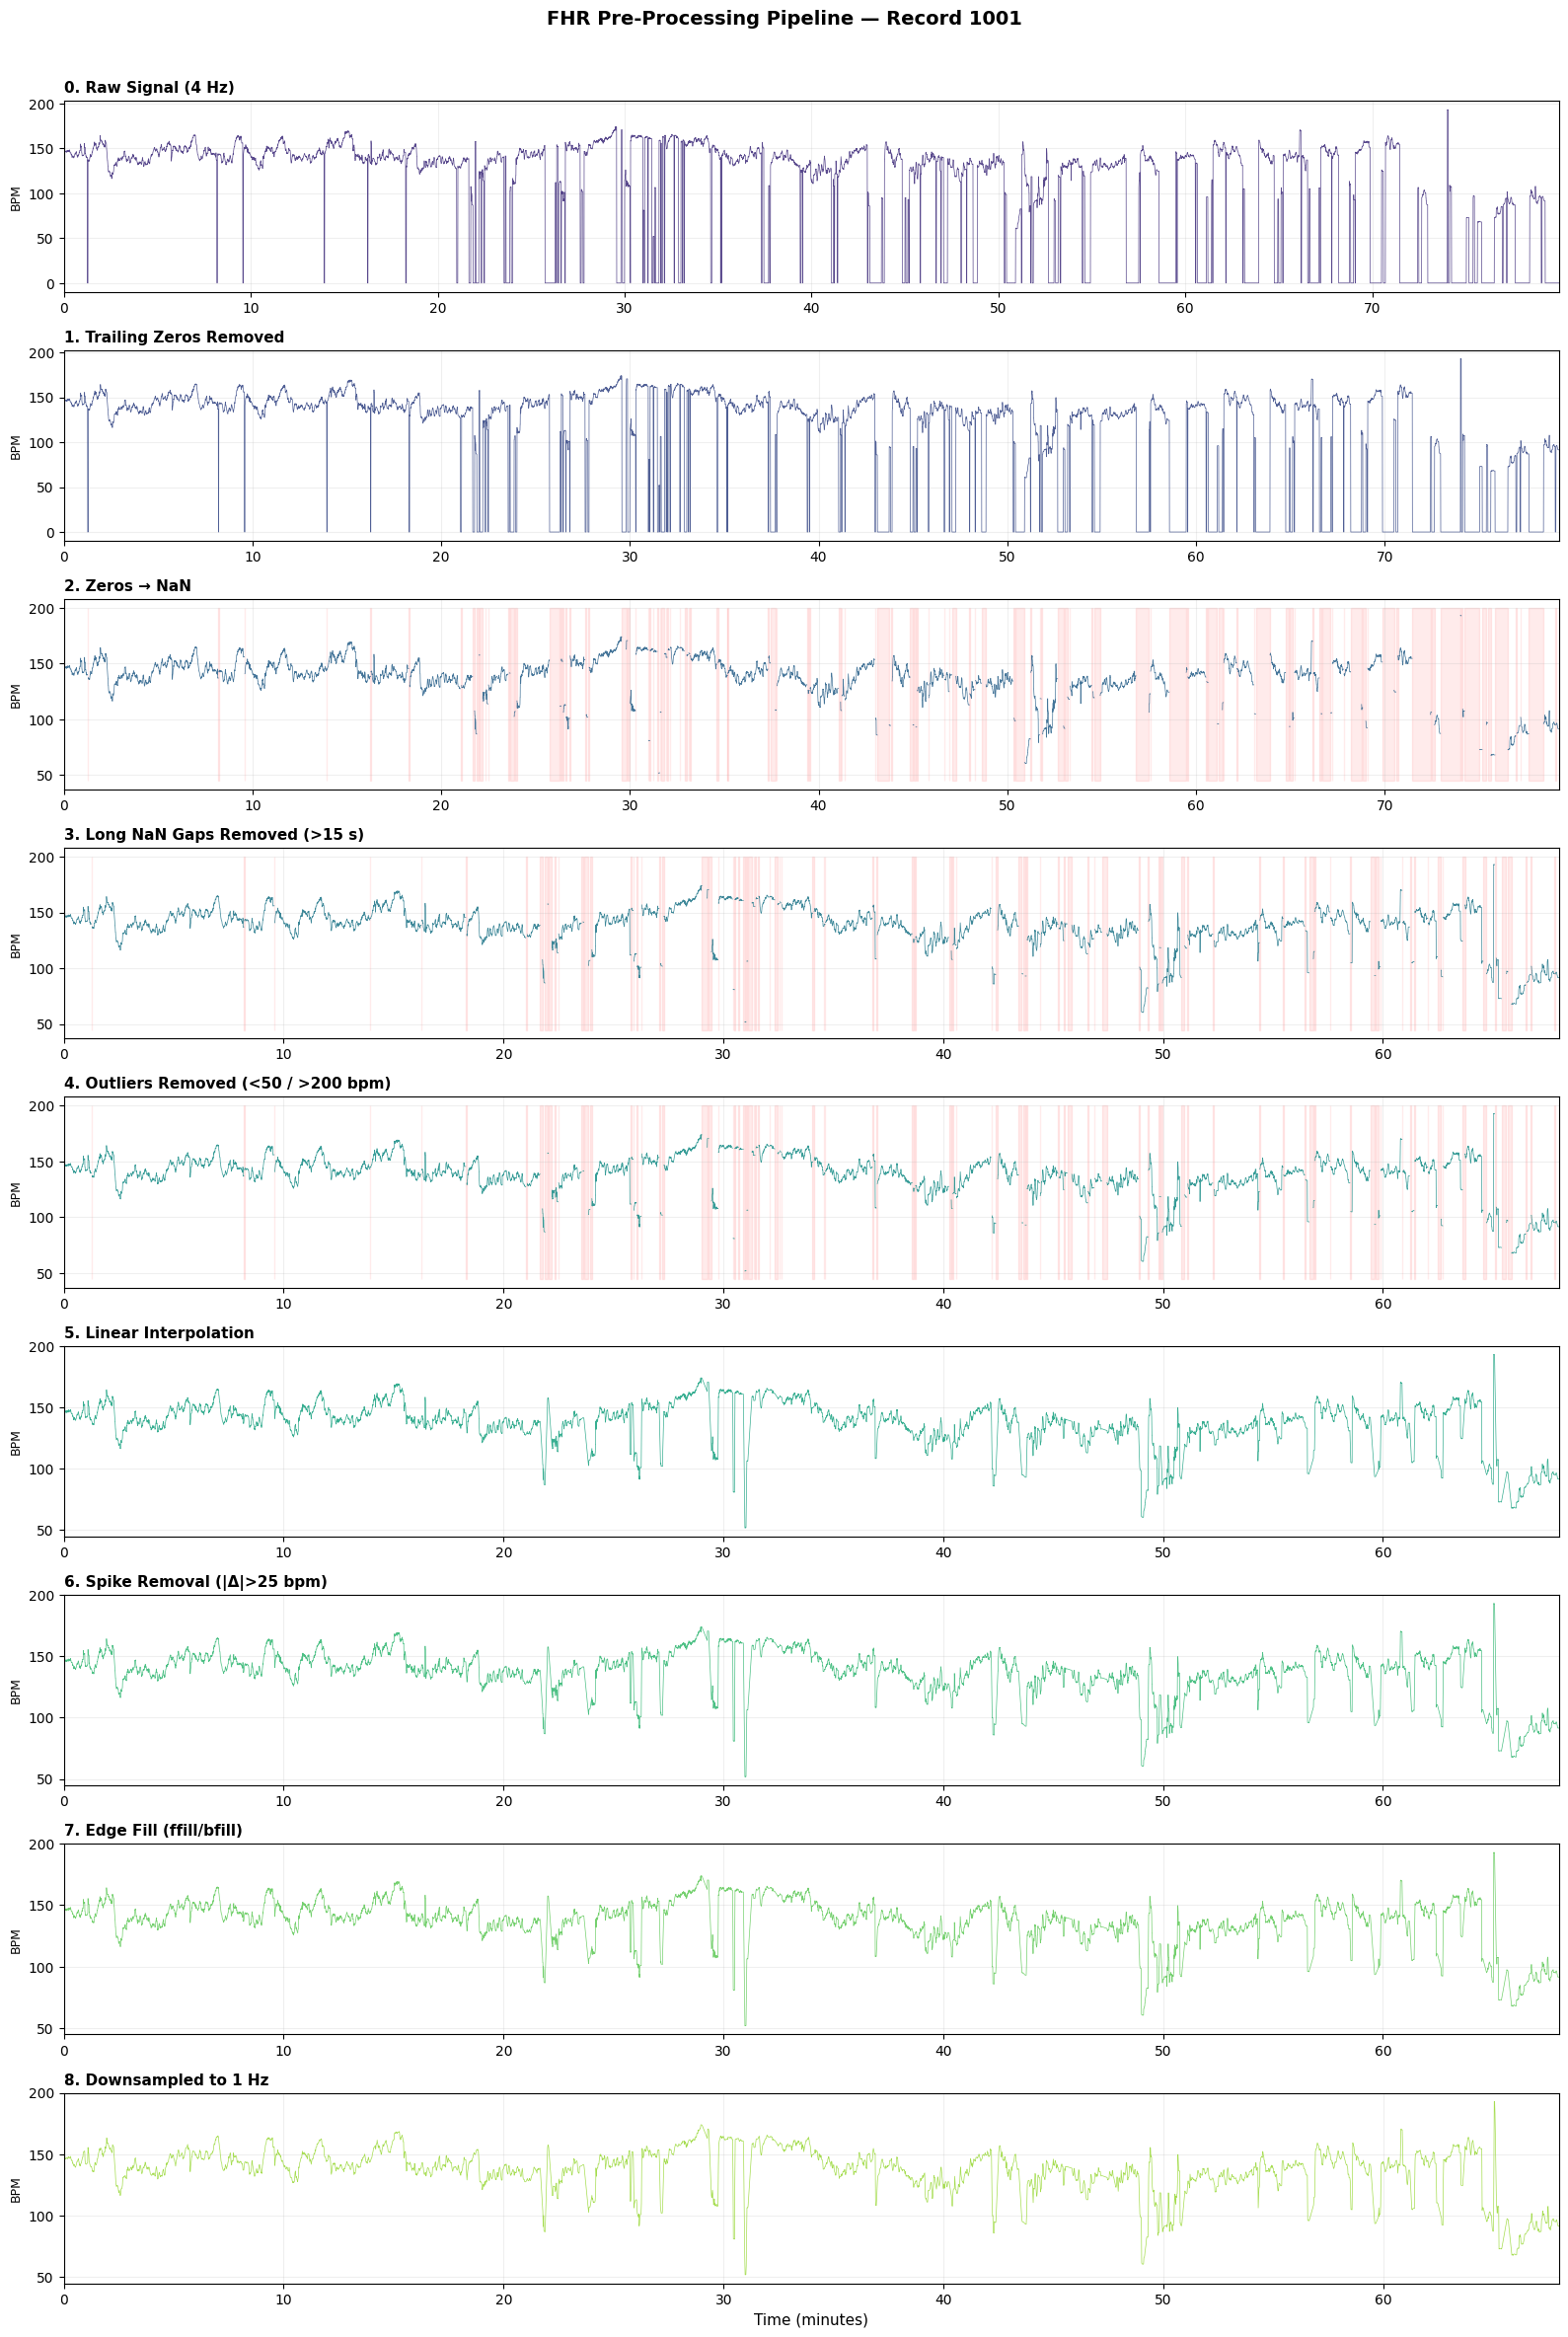


Record 1001: raw length = 19200 samples (80.0 min)
  After cleaning & downsampling: 4081 samples (68.0 min)


In [14]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Step-by-Step FHR Pre-Processing Pipeline
# ═══════════════════════════════════════════════════════════════════
# Pick one representative record to illustrate the pipeline
_demo_rid = sorted(signal_data.keys())[0]   # first available record
_demo_rec = wfdb.rdrecord(str(RAW_DATASET / _demo_rid))
_raw_fhr  = _demo_rec.p_signal[:, 0].copy()

# ---------- stage snapshots ----------
stages = {}

# 0  Raw signal
stages['0. Raw Signal (4 Hz)'] = _raw_fhr.copy()

# 1  Remove trailing zeros
_trimmed = np.array(remove_trailing_zeros(_raw_fhr), dtype=float)
stages['1. Trailing Zeros Removed'] = _trimmed.copy()

# 2  Replace 0 → NaN
_step2 = pd.Series(_trimmed.copy())
_step2.replace(0, np.nan, inplace=True)
stages['2. Zeros → NaN'] = _step2.values.copy()

# 3  Remove NaN gaps > 15 s (60 samples @ 4 Hz)
_step3 = _step2.copy()
_na = _step3.isnull()
_gg = _na.ne(_na.shift()).cumsum()
_gs = _step3.groupby(_gg.values).transform('size')
_step3 = _step3[~(_gs.ge(RAW_SAMPLING_RATE * 15 + 1) & _na)].reset_index(drop=True)
stages['3. Long NaN Gaps Removed (>15 s)'] = _step3.values.copy()

# 4  Outlier removal
_step4 = _step3.copy()
_step4[_step4 < 50]  = np.nan
_step4[_step4 > 200] = np.nan
stages['4. Outliers Removed (<50 / >200 bpm)'] = _step4.values.copy()

# 5  Linear interpolation
_step5 = _step4.interpolate(method='linear')
stages['5. Linear Interpolation'] = _step5.values.copy()

# 6  Spike removal + re-interpolation
_step6 = _step5.copy()
_diff  = _step6 - _step6.shift()
_step6[(_diff > 25) | (_diff < -25)] = np.nan
_step6 = _step6.interpolate(method='linear')
stages['6. Spike Removal (|Δ|>25 bpm)'] = _step6.values.copy()

# 7  Edge fill
_step7 = _step6.ffill().bfill()
stages['7. Edge Fill (ffill/bfill)'] = _step7.values.copy()

# 8  Downsample to 1 Hz
_step8 = _step7.values[::DOWNSAMPLE_FACTOR]
stages['8. Downsampled to 1 Hz'] = _step8.copy()

# ---------- plot ----------
n_stages = len(stages)
fig, axes = plt.subplots(n_stages, 1, figsize=(16, 2.6 * n_stages), sharex=False)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_stages))

for ax, (title, sig), color in zip(axes, stages.items(), colors):
    t = np.arange(len(sig)) / (1 if '1 Hz' in title else RAW_SAMPLING_RATE) / 60  # minutes
    ax.plot(t, sig, linewidth=0.5, color=color, alpha=0.9)
    ax.set_ylabel('BPM', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlim(t[0], t[-1])
    ax.grid(alpha=0.2)
    # Highlight NaN regions in red
    nan_mask = np.isnan(sig)
    if nan_mask.any():
        ax.fill_between(t, ax.get_ylim()[0], ax.get_ylim()[1],
                         where=nan_mask, color='red', alpha=0.08, label='NaN')

axes[-1].set_xlabel('Time (minutes)', fontsize=11)
fig.suptitle(f'FHR Pre-Processing Pipeline — Record {_demo_rid}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nRecord {_demo_rid}: raw length = {len(_raw_fhr)} samples ({len(_raw_fhr)/RAW_SAMPLING_RATE/60:.1f} min)")
print(f"  After cleaning & downsampling: {len(_step8)} samples ({len(_step8)/SAMPLING_RATE/60:.1f} min)")


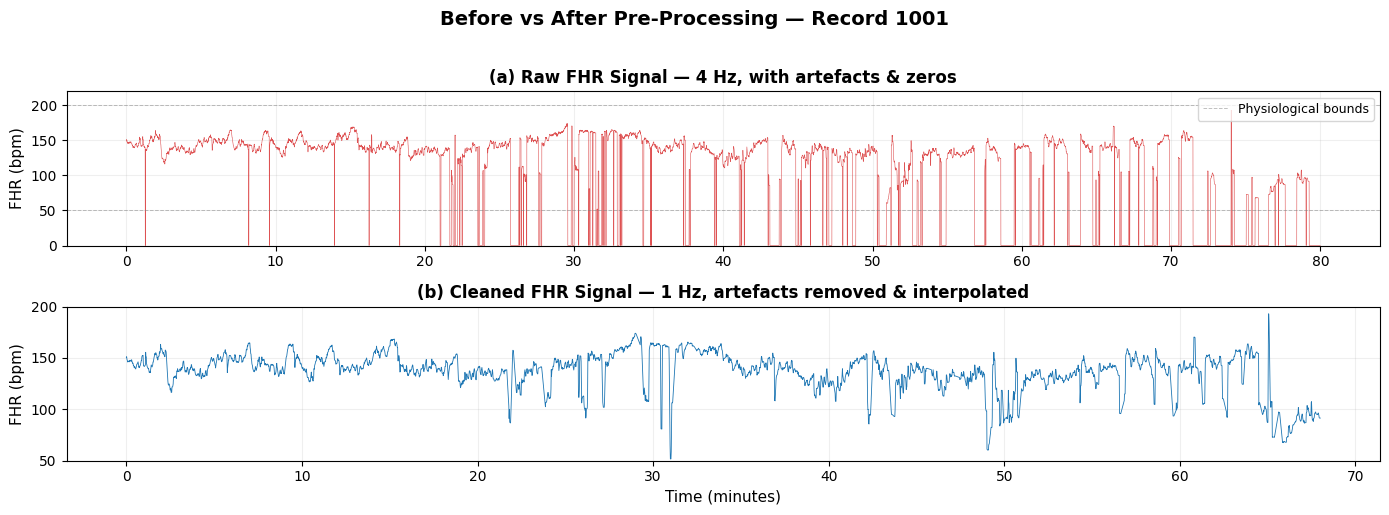

In [15]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Raw vs Cleaned FHR — Compact Before/After
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)

# Raw (4 Hz)
t_raw = np.arange(len(_raw_fhr)) / RAW_SAMPLING_RATE / 60
axes[0].plot(t_raw, _raw_fhr, linewidth=0.4, color='#d62728', alpha=0.8)
axes[0].set_ylabel('FHR (bpm)', fontsize=11)
axes[0].set_title('(a) Raw FHR Signal — 4 Hz, with artefacts & zeros', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 220)
axes[0].axhline(50, color='grey', ls='--', lw=0.7, alpha=0.5, label='Physiological bounds')
axes[0].axhline(200, color='grey', ls='--', lw=0.7, alpha=0.5)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.2)

# Cleaned + downsampled (1 Hz)
t_clean = np.arange(len(_step8)) / SAMPLING_RATE / 60
axes[1].plot(t_clean, _step8, linewidth=0.6, color='#1f77b4')
axes[1].set_ylabel('FHR (bpm)', fontsize=11)
axes[1].set_xlabel('Time (minutes)', fontsize=11)
axes[1].set_title('(b) Cleaned FHR Signal — 1 Hz, artefacts removed & interpolated', fontsize=12, fontweight='bold')
axes[1].set_ylim(50, 200)
axes[1].grid(alpha=0.2)

fig.suptitle(f'Before vs After Pre-Processing — Record {_demo_rid}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Poster Visual — 30-Minute Window Extraction Strategy

Each eligible record contributes up to **3 overlapping 30-minute windows per step** (Step 2 and Step 3),
anchored relative to the end of the recording (delivery). This controlled windowing ensures
consistent temporal coverage and increases data utilisation while preserving the grouped
cross-validation guarantee (all windows from one record remain in the same fold).

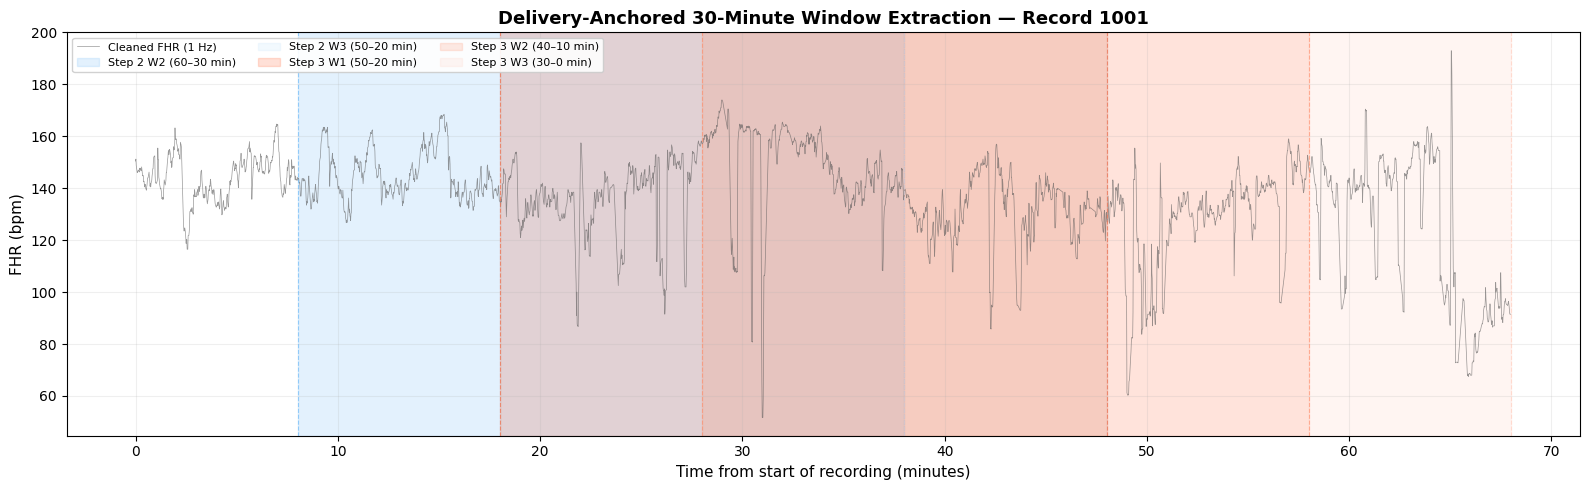

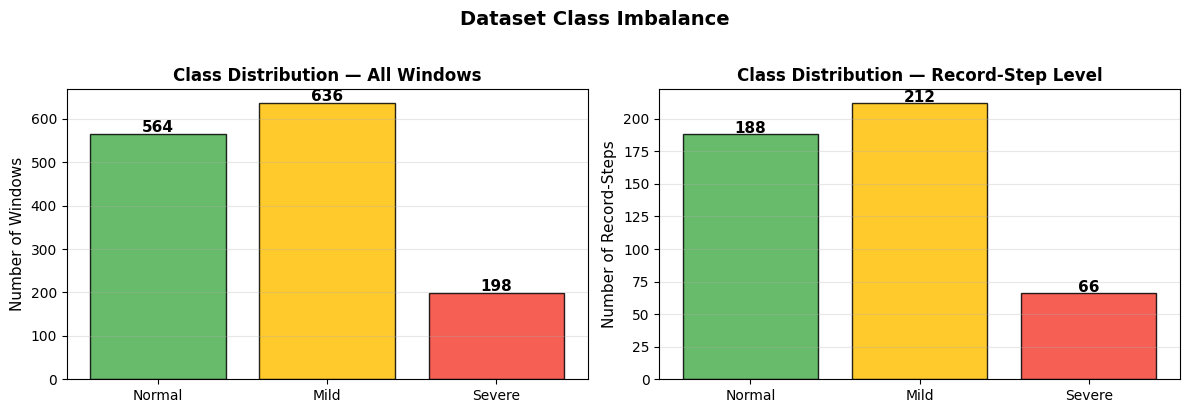

Windows: {'Normal': 564, 'Mild': 636, 'Severe': 198}
Record-steps: {'Normal': 188, 'Mild': 212, 'Severe': 66}


In [16]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Window Extraction — Delivery-Anchored Controlled Windows
# ═══════════════════════════════════════════════════════════════════

# Use the cleaned signal for the demo record
_demo_fhr_clean = signal_data[_demo_rid]['FHR']
_t_min = np.arange(len(_demo_fhr_clean)) / SAMPLING_RATE / 60

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(_t_min, _demo_fhr_clean, linewidth=0.5, color='#555555', alpha=0.6, label='Cleaned FHR (1 Hz)')

# Colour palette for windows
_win_colors = {'Step 2': ['#2196F3', '#64B5F6', '#BBDEFB'],
               'Step 3': ['#FF5722', '#FF8A65', '#FFCCBC']}

_sig_len = len(_demo_fhr_clean)
for step_num in CFG['step_numbers']:
    offsets_list = CFG['controlled_step_offsets'][step_num]
    cname = f'Step {step_num}'
    for wi, (off_start, off_end) in enumerate(offsets_list):
        s_idx = _sig_len - off_start * 60 * SAMPLING_RATE
        e_idx = _sig_len - off_end * 60 * SAMPLING_RATE if off_end > 0 else _sig_len
        if s_idx < 0:
            continue
        s_min = s_idx / SAMPLING_RATE / 60
        e_min = e_idx / SAMPLING_RATE / 60
        col = _win_colors[cname][wi % 3]
        ax.axvspan(s_min, e_min, alpha=0.18, color=col,
                   label=f'{cname} W{wi+1} ({off_start}–{off_end} min)')
        ax.axvline(s_min, color=col, ls='--', lw=0.8, alpha=0.6)
        ax.axvline(e_min, color=col, ls='--', lw=0.8, alpha=0.6)

ax.set_xlabel('Time from start of recording (minutes)', fontsize=11)
ax.set_ylabel('FHR (bpm)', fontsize=11)
ax.set_title(f'Delivery-Anchored 30-Minute Window Extraction — Record {_demo_rid}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Also show class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Windows per class
_cls_counts = [int(np.sum(y_all == c)) for c in range(NUM_CLASSES)]
bars = axes[0].bar(CLASS_NAMES, _cls_counts, color=['#4CAF50', '#FFC107', '#F44336'],
                   edgecolor='black', alpha=0.85)
for bar, cnt in zip(bars, _cls_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Windows', fontsize=11)
axes[0].set_title('Class Distribution — All Windows', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Record-steps per class
_step_targets = build_step_target_table(meta_all)
_rs_counts = [int(np.sum(_step_targets['label'].values == c)) for c in range(NUM_CLASSES)]
bars2 = axes[1].bar(CLASS_NAMES, _rs_counts, color=['#4CAF50', '#FFC107', '#F44336'],
                    edgecolor='black', alpha=0.85)
for bar, cnt in zip(bars2, _rs_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(cnt), ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Record-Steps', fontsize=11)
axes[1].set_title('Class Distribution — Record-Step Level', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Dataset Class Imbalance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Windows: {dict(zip(CLASS_NAMES, _cls_counts))}")
print(f"Record-steps: {dict(zip(CLASS_NAMES, _rs_counts))}")


## Poster Visual — Handcrafted FHR Feature Derivation

The model's **clinical feature branch** extracts 10 compact engineered features from
each 30-minute cleaned FHR window. These features capture statistical summaries,
variability, and clinically meaningful events (accelerations / decelerations) that
complement the raw-signal CNN branch.

| # | Feature | Description |
|---|---------|-------------|
| 1 | `mean_fhr` | Mean FHR across the window |
| 2 | `median_fhr` | Median FHR (robust centre) |
| 3 | `std_fhr` | Standard deviation of FHR |
| 4 | `iqr_fhr` | Inter-quartile range (Q75 − Q25) |
| 5 | `masd` | Mean absolute successive difference — short-term variability proxy |
| 6 | `minute_mean_std` | Std of 1-minute means — long-term variability proxy |
| 7 | `n_accel` | Number of accelerations (≥ +15 bpm above baseline for ≥ 15 s) |
| 8 | `n_decel` | Number of decelerations (≥ −15 bpm below baseline for ≥ 15 s) |
| 9 | `max_decel_depth` | Maximum depth of deceleration (bpm below baseline) |
| 10 | `missing_frac_prefill` | Fraction of missing/zero samples before final interpolation |

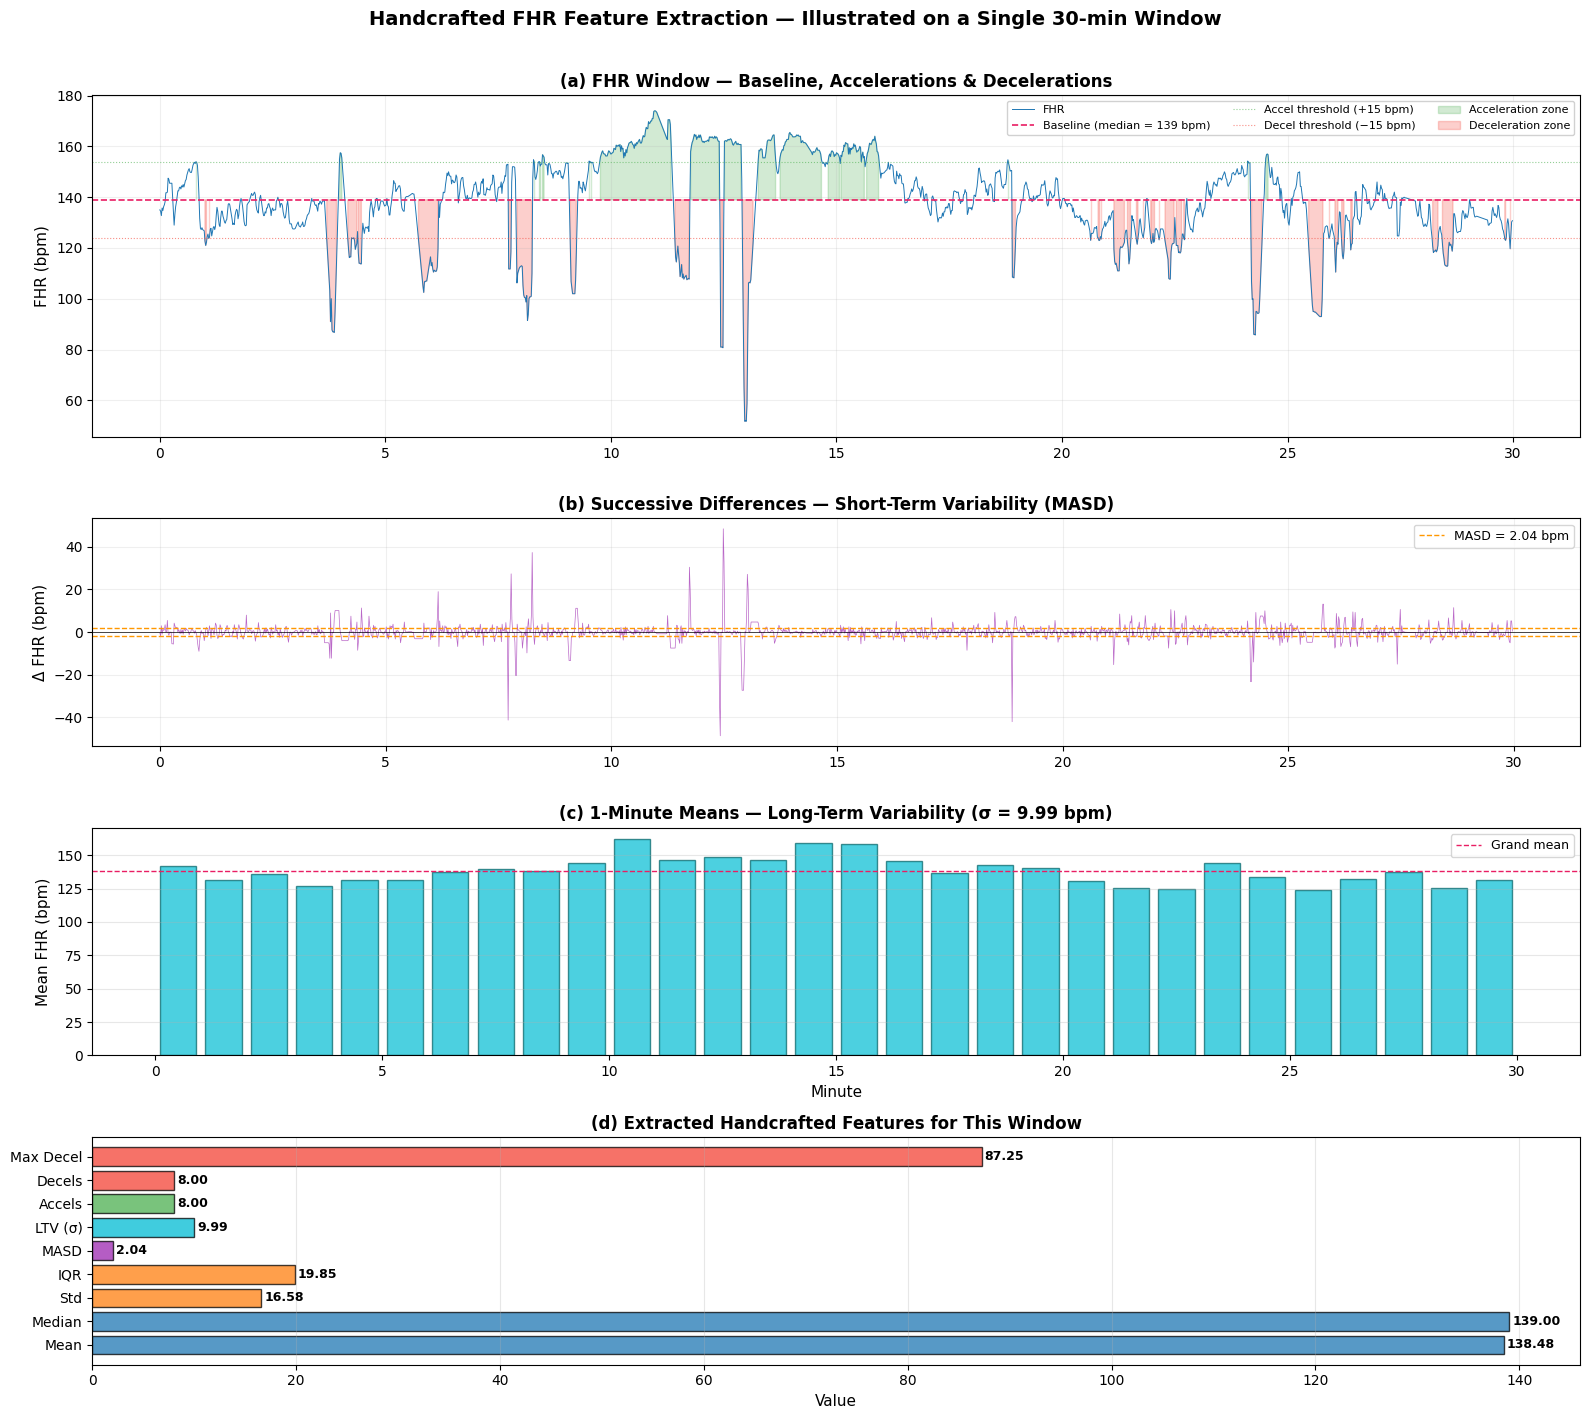


Extracted features for demo window:
  Mean                : 138.48
  Median              : 139.00
  Std                 : 16.58
  IQR                 : 19.85
  MASD                : 2.04
  LTV (σ)             : 9.99
  Accels              : 8.00
  Decels              : 8.00
  Max Decel           : 87.25


In [17]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Handcrafted FHR Feature Derivation on a Single Window
# ═══════════════════════════════════════════════════════════════════

# Pick the first window from the dataset
_demo_window = X_all[0, :, 0].copy()
_t_win = np.arange(len(_demo_window)) / SAMPLING_RATE / 60  # minutes
_baseline = float(np.median(_demo_window))
_deviation = _demo_window - _baseline

fig, axes = plt.subplots(4, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [3, 2, 2, 2]})

# ── Panel A: FHR signal with baseline, accelerations, decelerations ──
ax = axes[0]
ax.plot(_t_win, _demo_window, linewidth=0.7, color='#1f77b4', label='FHR')
ax.axhline(_baseline, color='#e91e63', ls='--', lw=1.2, label=f'Baseline (median = {_baseline:.0f} bpm)')
ax.axhline(_baseline + 15, color='#4CAF50', ls=':', lw=0.8, alpha=0.6, label='Accel threshold (+15 bpm)')
ax.axhline(_baseline - 15, color='#F44336', ls=':', lw=0.8, alpha=0.6, label='Decel threshold (−15 bpm)')

# Shade accelerations
_accel_mask = _deviation >= 15
ax.fill_between(_t_win, _baseline, _demo_window,
                where=_accel_mask, color='#4CAF50', alpha=0.25, label='Acceleration zone')

# Shade decelerations
_decel_mask = _deviation <= -15
ax.fill_between(_t_win, _baseline, _demo_window,
                where=_decel_mask, color='#F44336', alpha=0.25, label='Deceleration zone')

ax.set_ylabel('FHR (bpm)', fontsize=11)
ax.set_title('(a) FHR Window — Baseline, Accelerations & Decelerations', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right', framealpha=0.9)
ax.grid(alpha=0.2)

# ── Panel B: Short-Term Variability — successive differences ──
ax = axes[1]
_diffs = np.diff(_demo_window)
_t_diff = _t_win[:-1]
ax.plot(_t_diff, _diffs, linewidth=0.5, color='#9C27B0', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
_masd = float(np.mean(np.abs(_diffs)))
ax.axhline(_masd, color='#FF9800', ls='--', lw=1.0, label=f'MASD = {_masd:.2f} bpm')
ax.axhline(-_masd, color='#FF9800', ls='--', lw=1.0)
ax.set_ylabel('Δ FHR (bpm)', fontsize=11)
ax.set_title('(b) Successive Differences — Short-Term Variability (MASD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.2)

# ── Panel C: Long-Term Variability — 1-minute means ──
ax = axes[2]
_one_min_samp = 60 * SAMPLING_RATE
_n_min = len(_demo_window) // _one_min_samp
_min_means = [np.mean(_demo_window[j * _one_min_samp:(j + 1) * _one_min_samp]) for j in range(_n_min)]
_min_t = np.arange(_n_min) + 0.5  # centre of each minute
ax.bar(_min_t, _min_means, width=0.8, color='#00BCD4', edgecolor='#006064', alpha=0.7)
_ltv = float(np.std(_min_means))
ax.axhline(np.mean(_min_means), color='#e91e63', ls='--', lw=1.0, label=f'Grand mean')
ax.set_ylabel('Mean FHR (bpm)', fontsize=11)
ax.set_xlabel('Minute', fontsize=11)
ax.set_title(f'(c) 1-Minute Means — Long-Term Variability (σ = {_ltv:.2f} bpm)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Panel D: Statistical summary features ──
ax = axes[3]
_q25, _q75 = np.percentile(_demo_window, [25, 75])
_feats = {
    'Mean': float(np.mean(_demo_window)),
    'Median': float(np.median(_demo_window)),
    'Std': float(np.std(_demo_window)),
    'IQR': float(_q75 - _q25),
    'MASD': _masd,
    'LTV (σ)': _ltv,
    'Accels': int(_accel_mask.sum() > 0),  # Count later properly
    'Decels': int(_decel_mask.sum() > 0),
    'Max Decel': float(np.max(np.maximum(-_deviation, 0))),
}
# Compute actual accel/decel counts using the helper
_accel_count, _ = _count_episodes(_deviation, _accel_mask, 15 * SAMPLING_RATE)
_decel_count, _ = _count_episodes(-_deviation, _decel_mask, 15 * SAMPLING_RATE)
_feats['Accels'] = _accel_count
_feats['Decels'] = _decel_count

_feat_names = list(_feats.keys())
_feat_vals  = list(_feats.values())
_bar_colors = ['#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e',
               '#9C27B0', '#00BCD4', '#4CAF50', '#F44336', '#F44336']
bars = ax.barh(_feat_names, _feat_vals, color=_bar_colors, edgecolor='black', alpha=0.75)
for bar, val in zip(bars, _feat_vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Value', fontsize=11)
ax.set_title('(d) Extracted Handcrafted Features for This Window', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

fig.suptitle('Handcrafted FHR Feature Extraction — Illustrated on a Single 30-min Window',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nExtracted features for demo window:")
for name, val in _feats.items():
    print(f"  {name:20s}: {val:.2f}")


## Poster Visual — Data Augmentation Pipeline

Four time-series augmentation strategies are applied **only to training data** during each epoch.
These augmentations improve generalisation by simulating realistic signal variability:

1. **Time Warping** (σ = 0.10): Smooth non-linear stretching/compression of the time axis
2. **Amplitude Scaling** (σ = 0.10): Random per-sample scaling factor drawn from N(1, σ)
3. **Additive Gaussian Noise** (σ = 0.02): Mild white noise overlay
4. **Signal Loss Simulation** (5% gap, 2 gaps): Short random dropout segments filled by linear interpolation

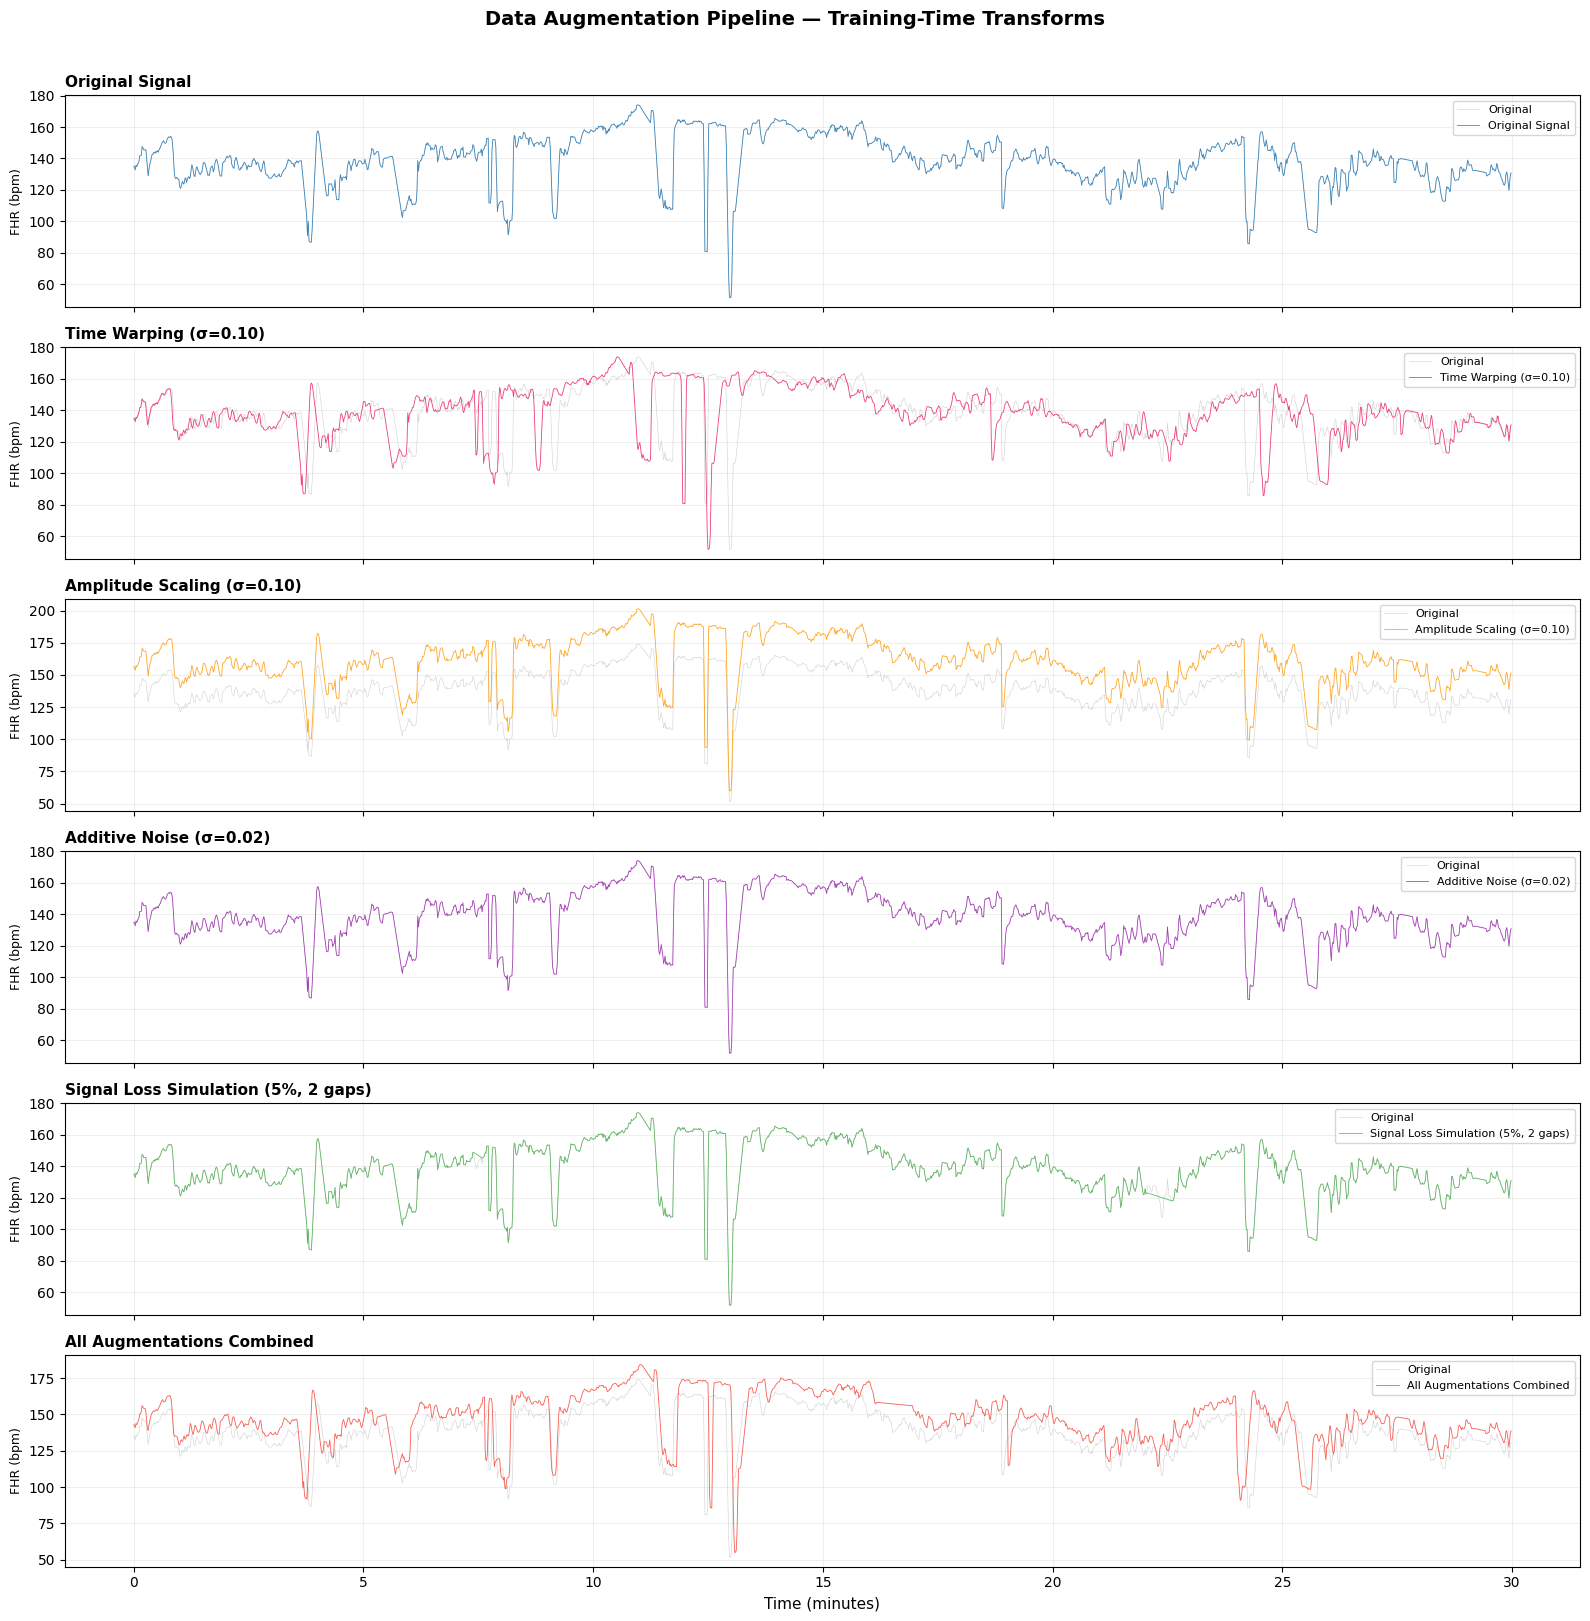

In [18]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Augmentation Pipeline — Effect of Each Transform
# ═══════════════════════════════════════════════════════════════════

# Use one sample window, expand to batch of 1 for augmentation functions
_aug_sample = X_all[0:1].copy()  # shape (1, 1800, 1)
_t_aug = np.arange(_aug_sample.shape[1]) / SAMPLING_RATE / 60

np.random.seed(42)  # reproducible demo

_aug_tw  = time_warp(_aug_sample, sigma=0.10)
_aug_as  = amplitude_scale(_aug_sample, sigma=0.10)
_aug_n   = additive_noise(_aug_sample, noise_std=0.02)
_aug_sl  = signal_loss_simulation(_aug_sample, max_gap_frac=0.05, n_gaps=2)
_aug_all = augment_signal(_aug_sample, CFG)

fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True)
_orig = _aug_sample[0, :, 0]

titles_data = [
    ('Original Signal', _orig, '#1f77b4'),
    ('Time Warping (σ=0.10)', _aug_tw[0, :, 0], '#e91e63'),
    ('Amplitude Scaling (σ=0.10)', _aug_as[0, :, 0], '#FF9800'),
    ('Additive Noise (σ=0.02)', _aug_n[0, :, 0], '#9C27B0'),
    ('Signal Loss Simulation (5%, 2 gaps)', _aug_sl[0, :, 0], '#4CAF50'),
    ('All Augmentations Combined', _aug_all[0, :, 0], '#F44336'),
]

for ax, (title, sig, color) in zip(axes, titles_data):
    ax.plot(_t_aug, _orig, linewidth=0.4, color='#BDBDBD', alpha=0.7, label='Original')
    ax.plot(_t_aug, sig, linewidth=0.6, color=color, alpha=0.85, label=title)
    ax.set_ylabel('FHR (bpm)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (minutes)', fontsize=11)
fig.suptitle('Data Augmentation Pipeline — Training-Time Transforms',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Poster Visual — Model Architecture Summary

### FHR-SegNet with Clinical Feature Branch

**Architecture Overview (Bullet Points for Poster):**

- **Input:** 1800 samples (30-min FHR @ 1 Hz), single-channel univariate time series
- **Stage 1 — Temporal Filtering:** Conv1D (32 filters, kernel 7) → BatchNorm → ReLU → AvgPool(4) → Dropout(0.4)
- **Stage 2 — Multi-Scale Feature Extraction:**
  - Three parallel SeparableConv1D branches with kernels 3, 7, 15 (captures short-, mid-, and long-range patterns)
  - Concatenation → 1×1 projection (32 filters) → BatchNorm → ReLU
  - **Squeeze-and-Excitation (SE) block** for per-channel attention
  - AvgPool(4) → Dropout(0.4)
- **Stage 3 — Residual Dilated Block:**
  - Two stacked SeparableConv1D (dilation rates 2, 4) with residual skip connection
  - SE attention block
  - AvgPool(2) → Dropout(0.4)
- **Global Average Pooling:** Reduces temporal dimension to a fixed-length vector
- **Clinical Feature Branch:** 10 handcrafted FHR features → Dense(16, ReLU) → Dropout(0.2)
- **Fusion:** Concatenate CNN embedding + clinical features → Dense(32, ReLU) → Dropout(0.4)
- **Output:** Dense(3, softmax) → 3-class probabilities (Normal / Mild / Severe)

**Key Design Choices:**
- **Multi-scale separable convolutions** capture both short-term variability and long-term trends in FHR
- **SE attention** adaptively re-weights channel importance — learns which temporal features matter most
- **Residual connections** with dilated convolutions increase receptive field without adding depth
- **Dual-branch fusion** combines raw signal representation with expert-derived clinical features
- **Label smoothing** (ε = 0.05) acts as a regulariser and improves calibration
- **Class weighting** (Normal: 0.9, Mild: 1.2, Severe: 2.5) addresses class imbalance
- **Record-step balanced accuracy** as early-stopping monitor prevents overfitting to the majority class

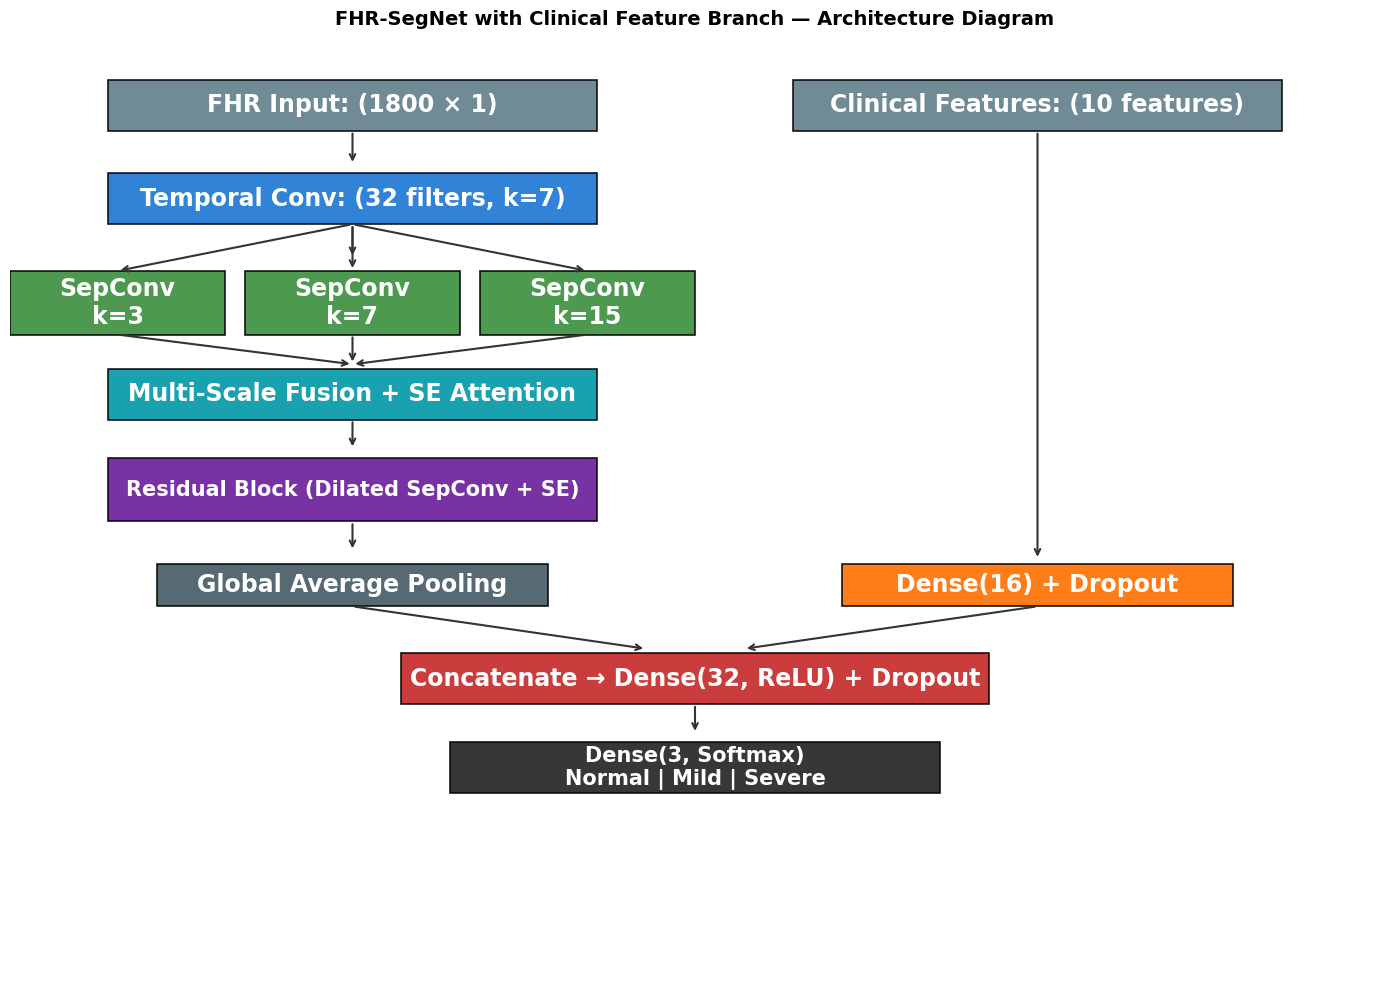

In [60]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Model Architecture Diagram (matplotlib-based)
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 22)
ax.axis('off')

def _draw_block(ax, x, y, w, h, text, color, fontsize=9, text_color='white'):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black',
                          linewidth=1.2, zorder=2, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=text_color, zorder=3)

def _arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

# ── Input ──
_draw_block(ax, 1, 20, 5, 1.2, 'FHR Input: (1800 × 1)', '#607D8B', fontsize=17)
_draw_block(ax, 8, 20, 5, 1.2, 'Clinical Features: (10 features)', '#607D8B', fontsize=17)

# ── Temporal Conv ──
_arrow(ax, 3.5, 20, 3.5, 19.2)
_draw_block(ax, 1, 17.8, 5, 1.2, 'Temporal Conv: (32 filters, k=7)', '#1976D2', fontsize=17)

# ── Multi-scale block ──
_arrow(ax, 3.5, 17.8, 3.5, 17.0)
_draw_block(ax, 0, 15.2, 2.2, 1.5, 'SepConv\nk=3', '#388E3C', fontsize=17)
_draw_block(ax, 2.4, 15.2, 2.2, 1.5, 'SepConv\nk=7', '#388E3C', fontsize=17)
_draw_block(ax, 4.8, 15.2, 2.2, 1.5, 'SepConv\nk=15', '#388E3C', fontsize=17)
_arrow(ax, 3.5, 17.8, 1.1, 16.7)
_arrow(ax, 3.5, 17.8, 3.5, 16.7)
_arrow(ax, 3.5, 17.8, 5.9, 16.7)

# ── Concat + projection + SE ──
_arrow(ax, 1.1, 15.2, 3.5, 14.5)
_arrow(ax, 3.5, 15.2, 3.5, 14.5)
_arrow(ax, 5.9, 15.2, 3.5, 14.5)
_draw_block(ax, 1, 13.2, 5, 1.2, 'Multi-Scale Fusion + SE Attention', '#0097A7', fontsize=17)

# ── Residual dilated block ──
_arrow(ax, 3.5, 13.2, 3.5, 12.5)
_draw_block(ax, 1, 10.8, 5, 1.5, 'Residual Block (Dilated SepConv + SE)', '#6A1B9A', fontsize=15)

# ── GAP ──
_arrow(ax, 3.5, 10.8, 3.5, 10.1)
_draw_block(ax, 1.5, 8.8, 4, 1.0, 'Global Average Pooling', '#455A64', fontsize=17)

# ── Clinical branch ──
_arrow(ax, 10.5, 20, 10.5, 9.9)
_draw_block(ax, 8.5, 8.8, 4, 1.0, 'Dense(16) + Dropout', '#FF6F00', fontsize=17)
1
# ── Fusion ──
_arrow(ax, 3.5, 8.8, 6.5, 7.8)
_arrow(ax, 10.5, 8.8, 7.5, 7.8)
_draw_block(ax, 4, 6.5, 6, 1.2, 'Concatenate → Dense(32, ReLU) + Dropout', '#C62828', fontsize=17)

# ── Output ──
_arrow(ax, 7, 6.5, 7, 5.8)
_draw_block(ax, 4.5, 4.4, 5, 1.2, 'Dense(3, Softmax)\nNormal | Mild | Severe', '#212121', fontsize=15)

ax.set_title('FHR-SegNet with Clinical Feature Branch — Architecture Diagram',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## Poster Visual — Normalisation & Cross-Validation Strategy

**Leakage-Safe Z-Score Normalisation:**
- Statistics (mean, std) computed **only on training fold** windows
- Applied identically to both training and validation windows
- Clinical features also Z-score normalised per-fold with train-only statistics

**10-Fold Stratified Grouped Cross-Validation:**
- All windows from the same **record** stay in the same fold (no data leakage)
- Stratification ensures balanced class proportions across folds
- Minimum Severe record-step threshold per validation fold for reliability
- Evaluation aggregated at **record-step level** (not window level)

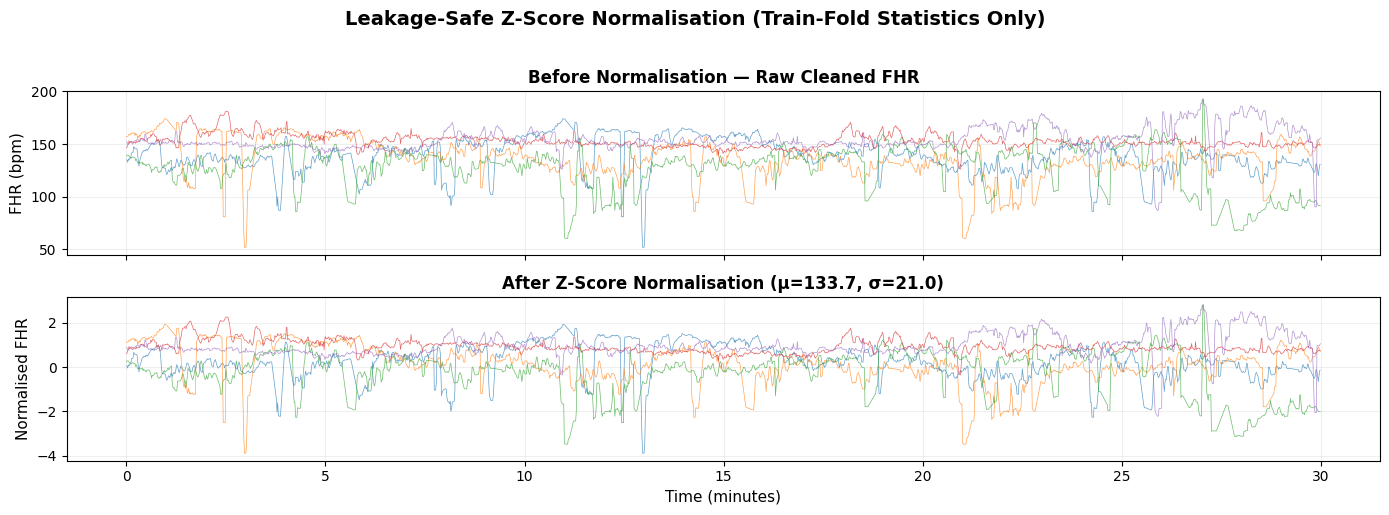

  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]


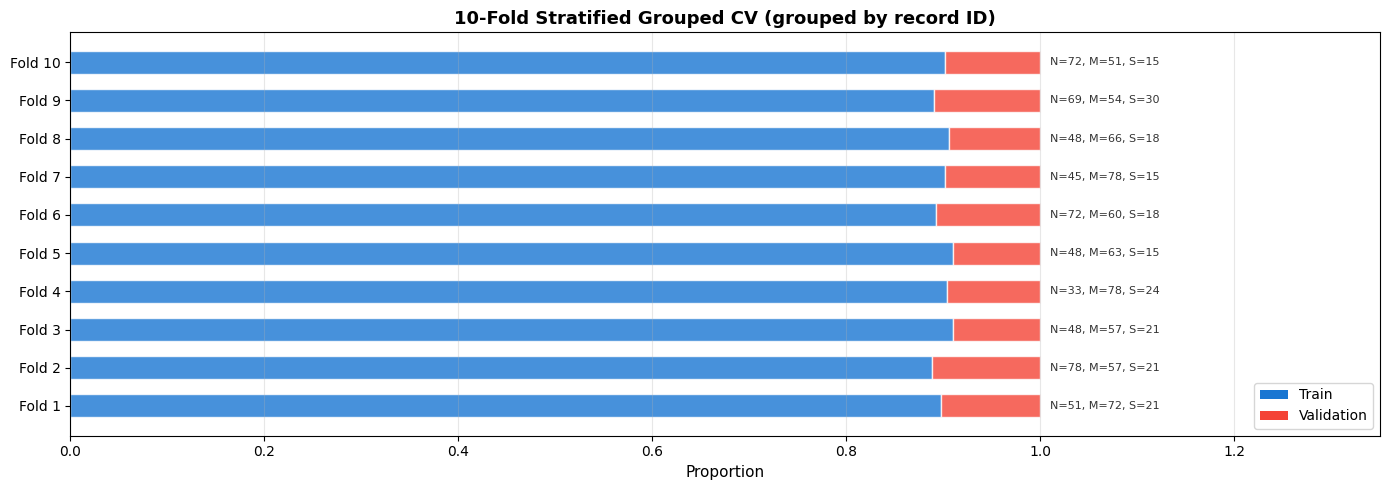

In [19]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Z-Score Normalisation — Before vs After
# ═══════════════════════════════════════════════════════════════════

# Demonstrate normalisation on a few windows
_norm_stats = compute_norm_stats(X_all)
_X_normed = apply_norm(X_all[:5].copy(), _norm_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
_t_norm = np.arange(X_all.shape[1]) / SAMPLING_RATE / 60

for i in range(min(5, len(X_all))):
    axes[0].plot(_t_norm, X_all[i, :, 0], linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('FHR (bpm)', fontsize=11)
axes[0].set_title('Before Normalisation — Raw Cleaned FHR', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.2)

for i in range(min(5, len(_X_normed))):
    axes[1].plot(_t_norm, _X_normed[i, :, 0], linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('Normalised FHR', fontsize=11)
axes[1].set_xlabel('Time (minutes)', fontsize=11)
axes[1].set_title(f'After Z-Score Normalisation (μ={_norm_stats["mean"]:.1f}, σ={_norm_stats["std"]:.1f})',
                  fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.2)

fig.suptitle('Leakage-Safe Z-Score Normalisation (Train-Fold Statistics Only)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Grouped Cross-Validation Schematic
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))
_n_folds = CFG['n_splits']

# Generate a sample fold split to visualise
_sample_folds = stratified_record_kfold_with_constraint(
    meta_all,
    n_splits=_n_folds,
    min_severe_records=CFG['min_severe_records'],
    max_attempts=10,
    cv_seed=CFG['cv_seed'],
)

for fold_i, (train_idx, val_idx) in enumerate(_sample_folds):
    _n_train = len(train_idx)
    _n_val = len(val_idx)
    _total = _n_train + _n_val
    _train_frac = _n_train / _total
    
    # Train bar
    ax.barh(fold_i, _train_frac, left=0, height=0.6,
            color='#1976D2', edgecolor='white', alpha=0.8)
    # Val bar
    ax.barh(fold_i, 1 - _train_frac, left=_train_frac, height=0.6,
            color='#F44336', edgecolor='white', alpha=0.8)
    
    # Class breakdown in val
    _val_y = y_all[val_idx]
    _val_counts = {CLASS_NAMES[c]: int(np.sum(_val_y == c)) for c in range(NUM_CLASSES)}
    ax.text(1.01, fold_i, f"N={_val_counts['Normal']}, M={_val_counts['Mild']}, S={_val_counts['Severe']}",
            va='center', fontsize=8, color='#333')

ax.set_yticks(range(_n_folds))
ax.set_yticklabels([f'Fold {i+1}' for i in range(_n_folds)], fontsize=10)
ax.set_xlabel('Proportion', fontsize=11)
ax.set_xlim(0, 1.35)
ax.set_title(f'{_n_folds}-Fold Stratified Grouped CV (grouped by record ID)',
             fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#1976D2', label='Train'),
                   Patch(facecolor='#F44336', label='Validation')],
          fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


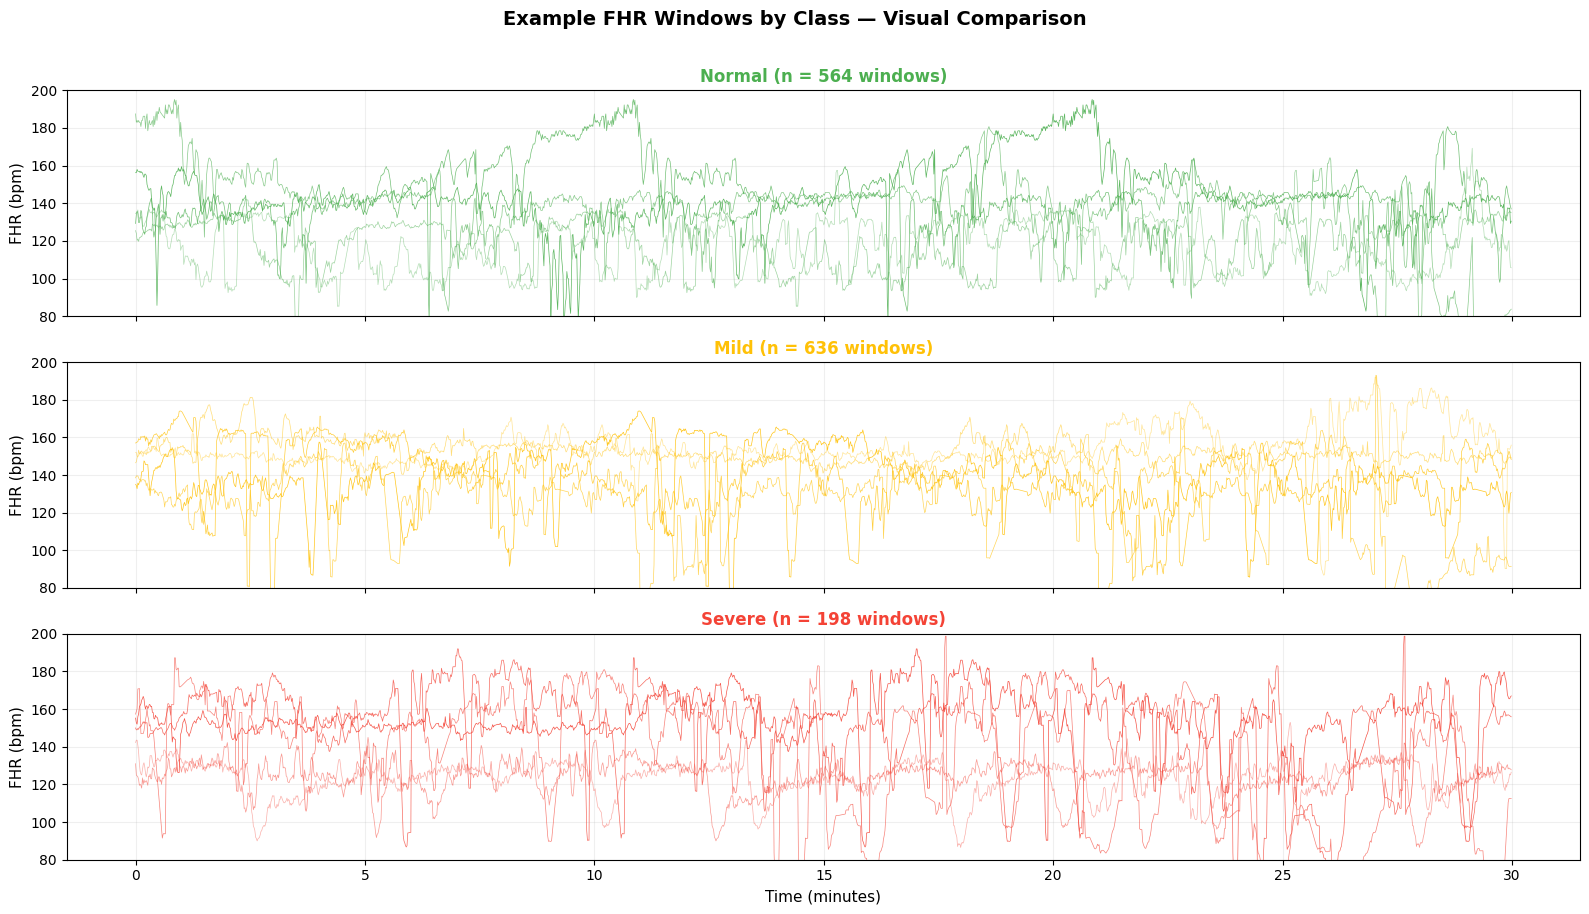

In [20]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: FHR Signal Examples by Class (Normal / Mild / Severe)
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True, sharey=True)
_t_cls = np.arange(X_all.shape[1]) / SAMPLING_RATE / 60
_cls_colors = ['#4CAF50', '#FFC107', '#F44336']

for cls_id, (ax, name, color) in enumerate(zip(axes, CLASS_NAMES, _cls_colors)):
    _cls_idx = np.where(y_all == cls_id)[0]
    # Plot up to 5 example windows
    for i, idx in enumerate(_cls_idx[:5]):
        alpha = 0.9 - i * 0.12
        ax.plot(_t_cls, X_all[idx, :, 0], linewidth=0.5, color=color, alpha=alpha)
    ax.set_ylabel('FHR (bpm)', fontsize=11)
    ax.set_title(f'{name} (n = {len(_cls_idx)} windows)', fontsize=12, fontweight='bold', color=color)
    ax.grid(alpha=0.2)
    ax.set_ylim(80, 200)

axes[-1].set_xlabel('Time (minutes)', fontsize=11)
fig.suptitle('Example FHR Windows by Class — Visual Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


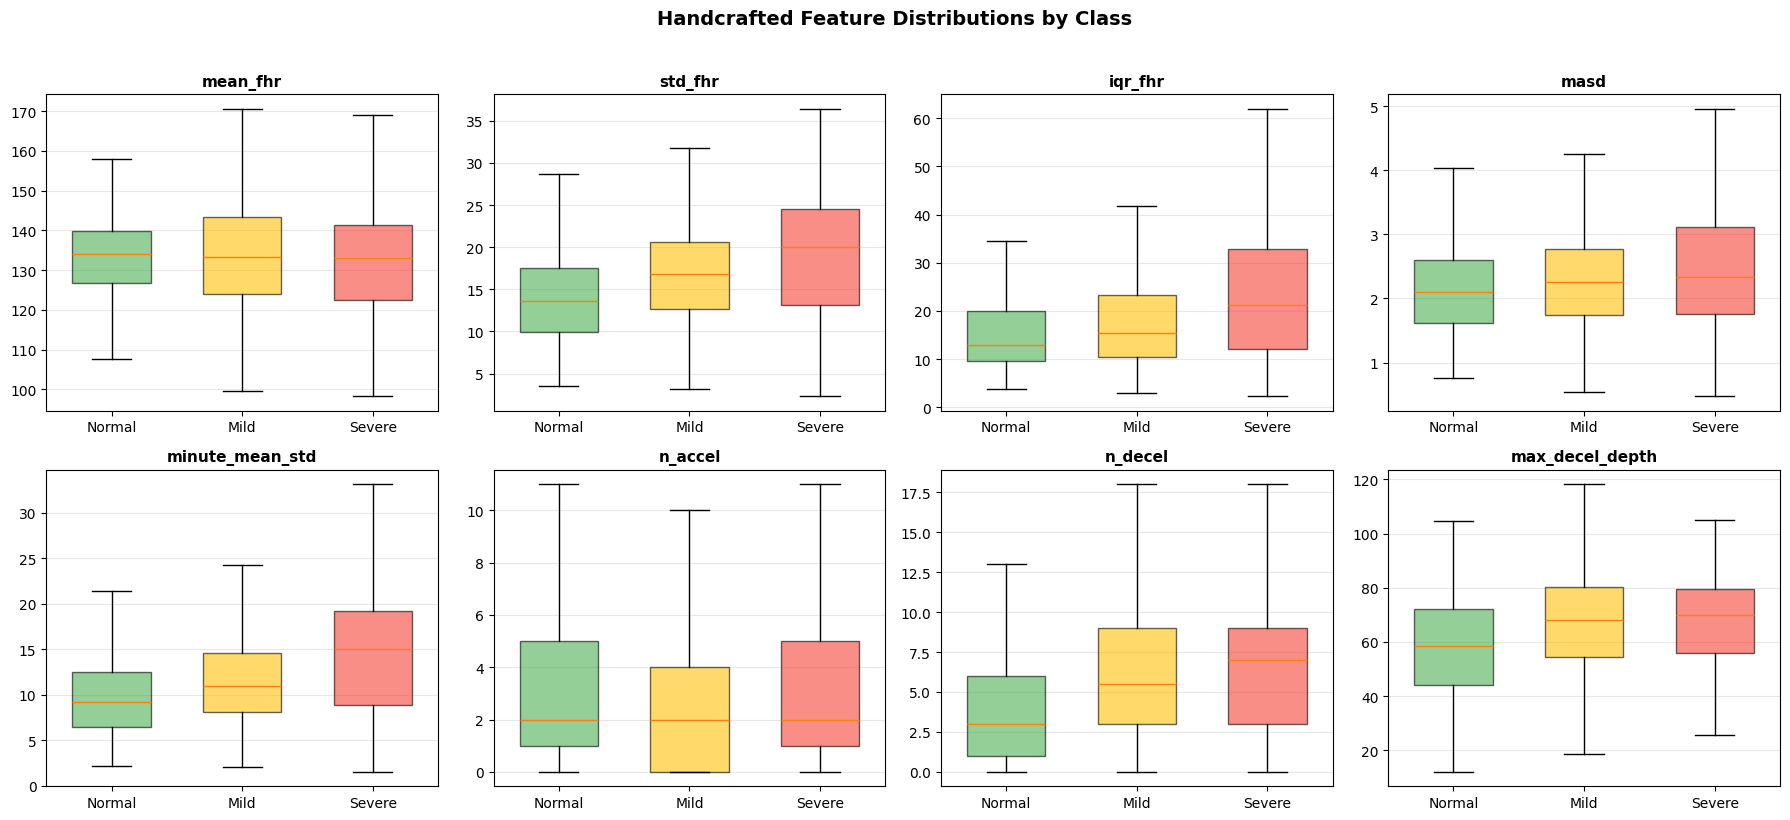

In [21]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: Engineered Feature Distributions by Class
# ═══════════════════════════════════════════════════════════════════

# Compute features for all windows
_clin_all = compute_clinical_features(
    X_all, fs=SAMPLING_RATE,
    missing_frac_prefill=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
)
_clin_df = pd.DataFrame(_clin_all, columns=CLINICAL_FEATURE_NAMES)
_clin_df['class'] = [CLASS_NAMES[c] for c in y_all]

# Box plots for key discriminative features
_key_feats = ['mean_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std',
              'n_accel', 'n_decel', 'max_decel_depth']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, feat in enumerate(_key_feats):
    ax = axes[i]
    data_by_class = [_clin_df[_clin_df['class'] == cn][feat].values for cn in CLASS_NAMES]
    bp = ax.boxplot(data_by_class, labels=CLASS_NAMES, patch_artist=True,
                    widths=0.6, showfliers=False)
    for patch, color in zip(bp['boxes'], _cls_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Handcrafted Feature Distributions by Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Key Points to Mention on the Poster

### 1. Problem Statement
- Automated classification of intrapartum CTG (cardiotocography) recordings into **Normal**, **Mild**, and **Severe** categories
- Clinical goal: early detection of fetal distress to support timely intervention decisions
- Challenge: extreme **class imbalance** (few severe cases), noisy physiological signals, and subjective expert labelling

### 2. Dataset — CTU-UHB
- **552 CTU-UHB** intrapartum CTG recordings (publicly available benchmark)
- FHR (fetal heart rate) signals sampled at **4 Hz**, cleaned and downsampled to **1 Hz**
- Labels obtained via **expert majority voting** across multiple annotators for Steps 2 and 3 of labour
- Each record-step can contribute up to **3 overlapping 30-minute windows** (controlled windowing strategy)

### 3. Pre-Processing Pipeline
- 8-step cleaning pipeline: trailing-zero removal → zero→NaN → long-gap removal → outlier clipping → linear interpolation → spike removal → edge fill → downsampling
- Max 16% missing-data threshold per window — rejects unreliable segments
- All cleaning at native 4 Hz, then decimate to 1 Hz for model input

### 4. Feature Engineering (Dual-Branch Approach)
- **Raw signal branch:** CNN directly learns temporal representations from the 1800-sample FHR window
- **Handcrafted feature branch:** 10 clinically motivated features:
  - Statistical: mean, median, std, IQR
  - Variability: MASD (short-term), minute-mean std (long-term)
  - Clinical events: acceleration count, deceleration count, max deceleration depth
  - Data quality: missing fraction before interpolation
- Features Z-score normalised per fold using **training-only statistics** (no leakage)

### 5. Model Architecture — FHR-SegNet
- Multi-scale **separable convolutions** (kernels 3, 7, 15) capture patterns at different temporal granularities
- **Squeeze-and-Excitation** (SE) attention learns per-channel importance
- **Residual dilated blocks** (dilation 2, 4) expand receptive field without depth overhead
- Dual-branch **late fusion** of CNN embedding + handcrafted features
- 3-class **softmax** output with **label smoothing** (ε = 0.05)

### 6. Training Strategy
- **10-fold stratified grouped CV** — all windows from one patient in the same fold (zero leakage)
- **Manual class weights** (Normal: 0.9, Mild: 1.2, Severe: 2.5) to address imbalance
- Early stopping on **record-step balanced accuracy** — prevents majority-class overfitting
- **Data augmentation** (training only): time warping, amplitude scaling, Gaussian noise, signal loss simulation
- Adam optimiser, LR = 1e-3, batch size = 16, patience = 20 epochs

### 7. Evaluation Protocol
- Predictions aggregated at **record-step level** via mean probability averaging across multiple windows
- Metrics: **balanced accuracy**, **macro F1**, per-class precision/recall/F1
- Separate tracking of fold reliability based on minimum Severe step-units in validation

### 8. Why This Matters
- Addresses a real clinical need: objective, reproducible CTG interpretation
- Dual-branch architecture leverages both learned and expert-derived features
- Rigorous grouped CV prevents optimistic bias from data leakage
- Record-step-level evaluation respects the clinical decision granularity

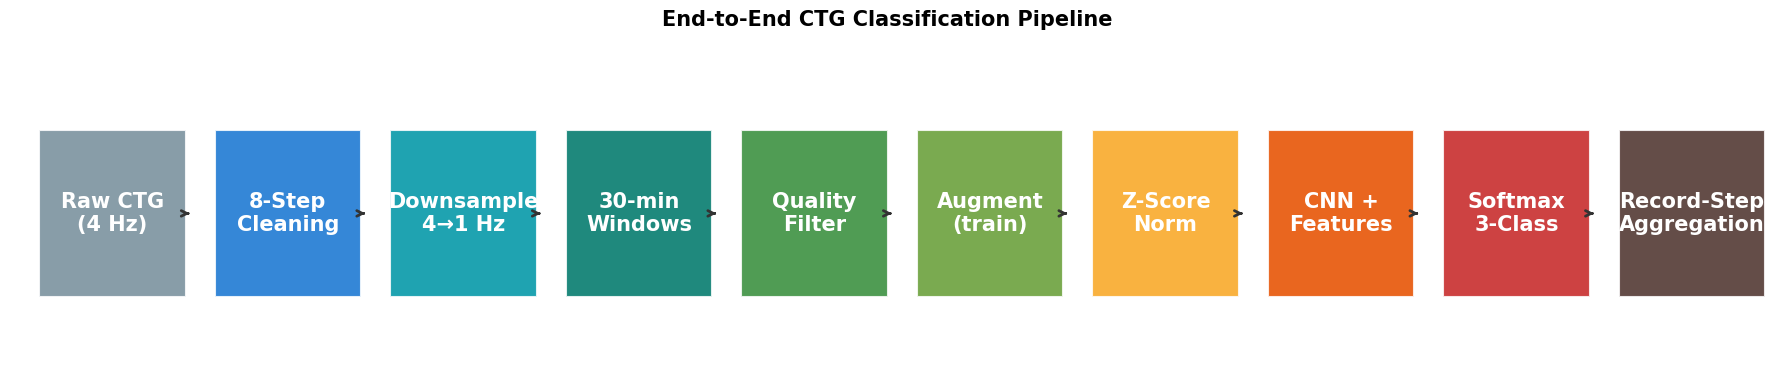

All poster visuals generated. Run cells above to reproduce inline. No model training required.


In [30]:
# ═══════════════════════════════════════════════════════════════════
# POSTER VISUAL: End-to-End Pipeline Overview Diagram
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(18, 4))
ax.set_xlim(0, 18)
ax.set_ylim(0, 4)
ax.axis('off')

_pipe_steps = [
    ('Raw CTG\n(4 Hz)', '#78909C'),
    ('8-Step\nCleaning', '#1976D2'),
    ('Downsample\n4→1 Hz', '#0097A7'),
    ('30-min\nWindows', '#00796B'),
    ('Quality\nFilter', '#388E3C'),
    ('Augment\n(train)', '#689F38'),
    ('Z-Score\nNorm', '#F9A825'),
    ('CNN +\nFeatures', '#E65100'),
    ('Softmax\n3-Class', '#C62828'),
    ('Record-Step\nAggregation', '#4E342E'),
]

_box_w = 1.5
_gap = 0.3
_box_h = 2.0
_y0 = 1.0

for i, (label, color) in enumerate(_pipe_steps):
    x = i * (_box_w + _gap) + 0.3
    rect = plt.Rectangle((x, _y0), _box_w, _box_h, facecolor=color,
                          edgecolor='white', linewidth=1.5, alpha=0.88, zorder=2)
    ax.add_patch(rect)
    ax.text(x + _box_w / 2, _y0 + _box_h / 2, label, ha='center', va='center',
            fontsize=15, fontweight='bold', color='white', zorder=3)
    
    # Arrow to next
    if i < len(_pipe_steps) - 1:
        ax.annotate('', xy=(x + _box_w + _gap * 0.15, _y0 + _box_h / 2),
                    xytext=(x + _box_w + 0.02, _y0 + _box_h / 2),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#333'))

ax.set_title('End-to-End CTG Classification Pipeline',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("All poster visuals generated. Run cells above to reproduce inline. No model training required.")


## 12. Main Experiment Runner

This short plan runs the **standard 3-class softmax baseline first** on **Step 2 + Step 3** 30-minute windows.


Key points:

- grouped CV still splits by `rec_id`

- Step 1 is excluded entirely

- engineered features are scaled per fold using training statistics only

- metrics are now reported at the **record-step level** so mixed Step 2 / Step 3 labels are handled consistently



######################################################################
# EXPERIMENT A: Step 2 + Step 3 Softmax Fixed Class Weights
######################################################################

Dataset: 1398 windows from 466 record-steps across 336 records
Window shape: (1398, 1800, 1)
Steps: {2: 399, 3: 999}
Classes: {'Normal': 564, 'Mild': 636, 'Severe': 198}
Engineered features: ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']

Running fixed class-weight experiment
Manual class weights: {0: 0.9, 1: 1.2, 2: 2.5}
Computing engineered features from cleaned FHR windows...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV with >= 10 Severe step-units/fold...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10
  Validation qualit

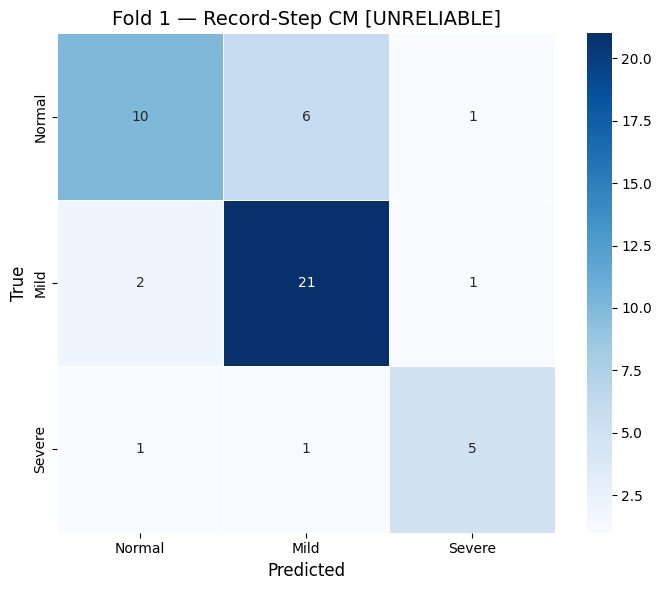


FOLD 2 / 10
  Validation quality: UNRELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3626 - loss: 1.3851  val_record_step_balanced_accuracy: 0.4297
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.4243 - loss: 1.3731 - val_accuracy: 0.3205 - val_loss: 1.1003 - val_record_step_balanced_accuracy: 0.4297 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4682 - loss: 1.2777  val_record_ste

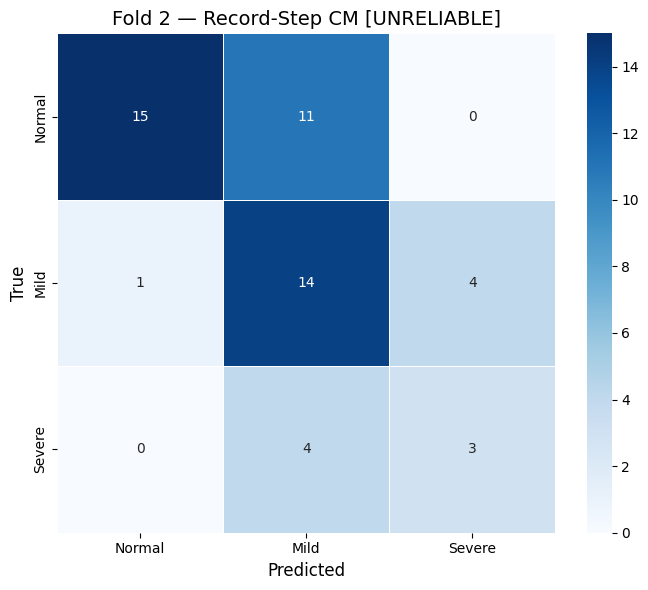


FOLD 3 / 10
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3630 - loss: 1.4180  val_record_step_balanced_accuracy: 0.3958
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4025 - loss: 1.3584 - val_accuracy: 0.4921 - val_loss: 1.0592 - val_record_step_balanced_accuracy: 0.3958 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5097 - loss: 1.3040  val_record_ste

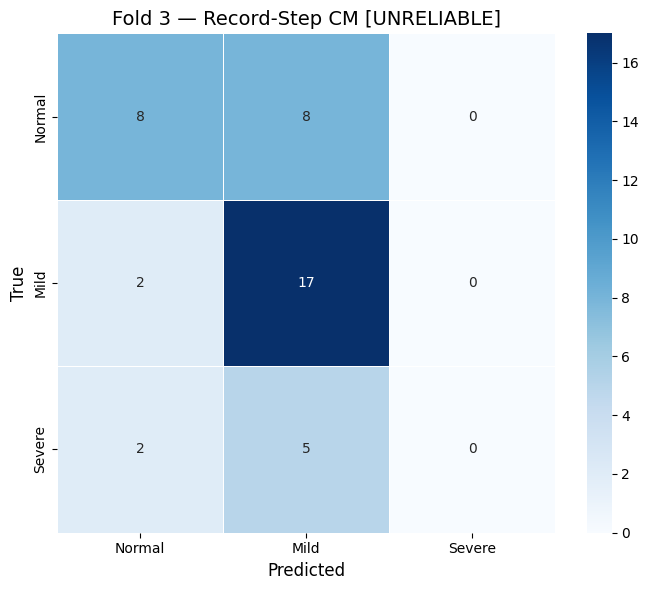


FOLD 4 / 10
  Validation quality: UNRELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 10)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3011 - loss: 1.4655  val_record_step_balanced_accuracy: 0.4522
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.3698 - loss: 1.4356 - val_accuracy: 0.3259 - val_loss: 1.1240 - val_record_step_balanced_accuracy: 0.4522 - learning_rate: 0.0010
Epoch 2/100
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4536 - loss: 1.2955  val_record_ste

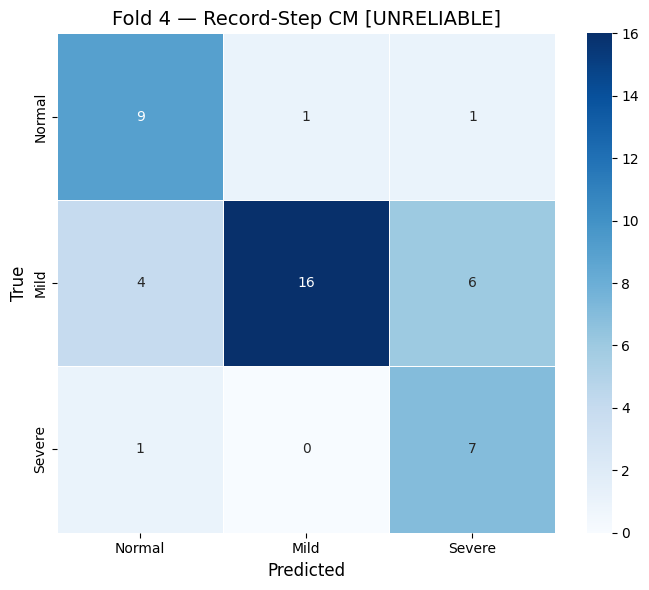


FOLD 5 / 10
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3751 - loss: 1.6031  val_record_step_balanced_accuracy: 0.3790
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.3876 - loss: 1.4706 - val_accuracy: 0.4921 - val_loss: 1.0386 - val_record_step_balanced_accuracy: 0.3790 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4624 - loss: 1.3882  val_record_ste

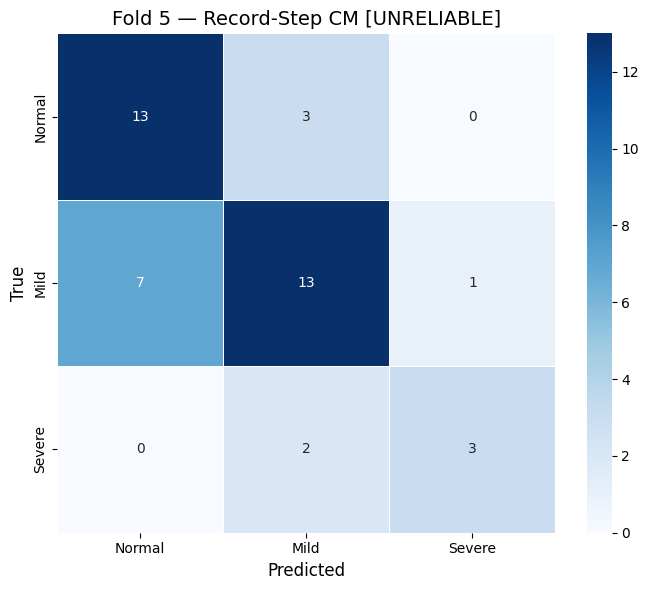


FOLD 6 / 10
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4023 - loss: 1.5479  val_record_step_balanced_accuracy: 0.3444
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.4183 - loss: 1.4536 - val_accuracy: 0.4933 - val_loss: 1.0700 - val_record_step_balanced_accuracy: 0.3444 - learning_rate: 0.0010
Epoch 2/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4684 - loss: 1.3458  val_record_ste

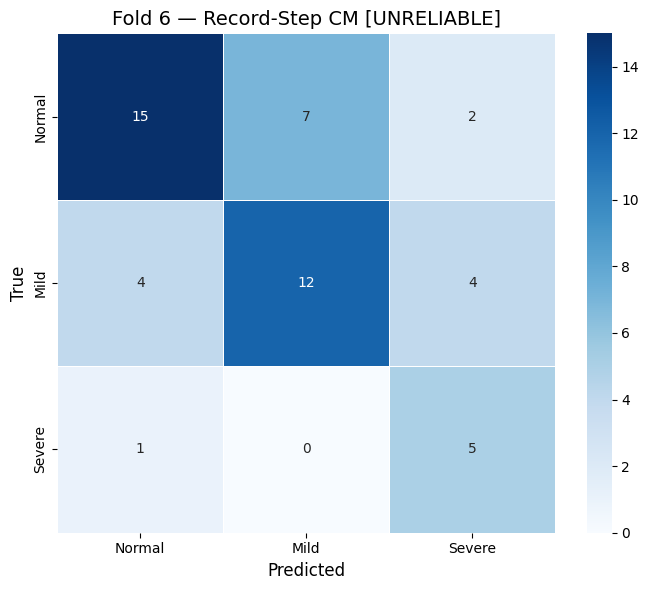


FOLD 7 / 10
  Validation quality: UNRELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4094 - loss: 1.4042  val_record_step_balanced_accuracy: 0.3675
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4230 - loss: 1.3659 - val_accuracy: 0.5290 - val_loss: 1.0218 - val_record_step_balanced_accuracy: 0.3675 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4969 - loss: 1.3289  val_record_ste

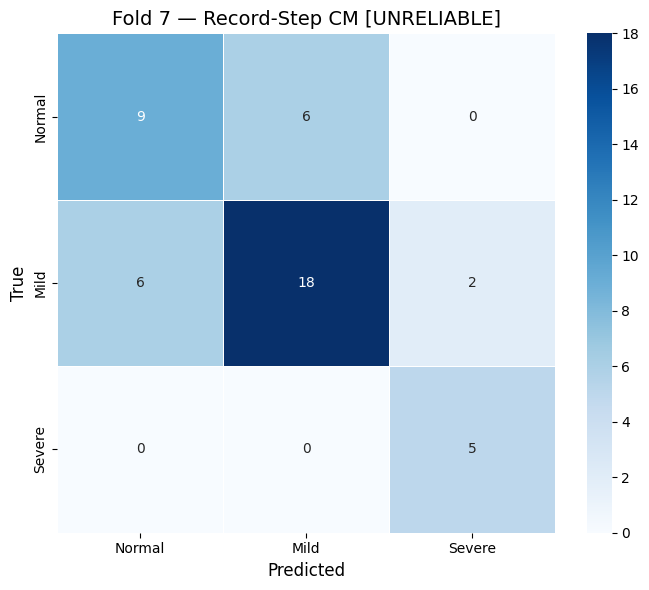


FOLD 8 / 10
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3919 - loss: 1.4249  val_record_step_balanced_accuracy: 0.4672
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.3863 - loss: 1.4013 - val_accuracy: 0.4773 - val_loss: 1.0468 - val_record_step_balanced_accuracy: 0.4672 - learning_rate: 0.0010
Epoch 2/100
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4489 - loss: 1.3189  val_record_ste

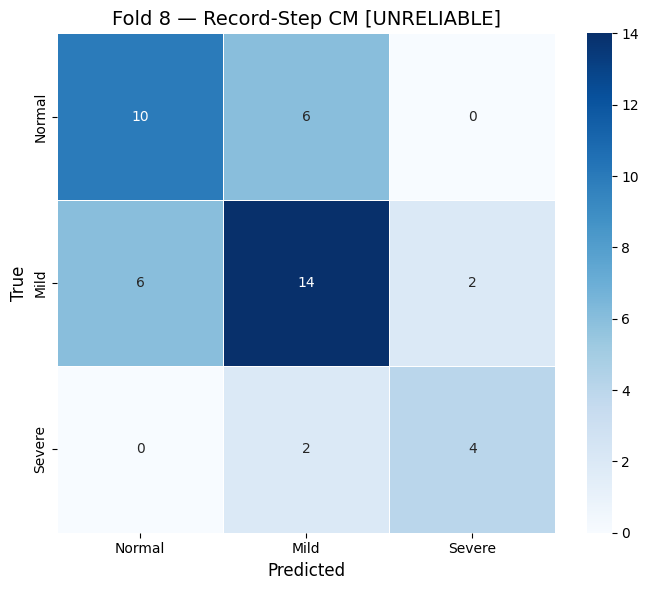


FOLD 9 / 10
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 10)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3706 - loss: 1.4238  val_record_step_balanced_accuracy: 0.4779
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.4088 - loss: 1.3956 - val_accuracy: 0.4641 - val_loss: 1.0493 - val_record_step_balanced_accuracy: 0.4779 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4656 - loss: 1.3029  val_record_ste

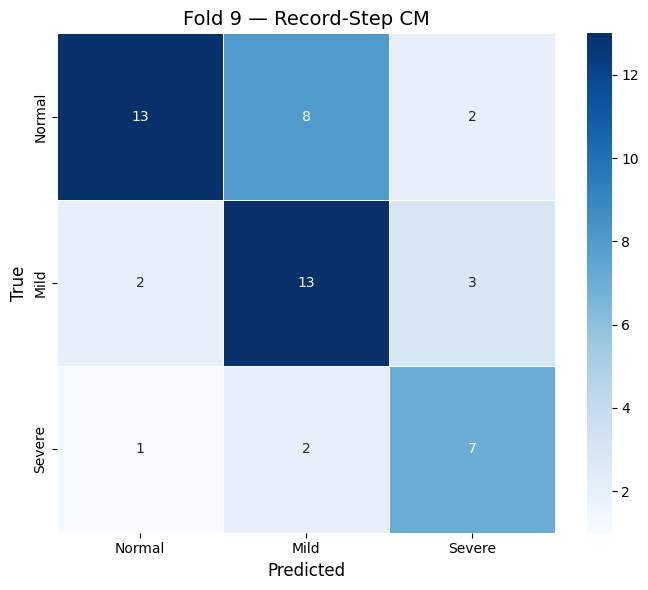


FOLD 10 / 10
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4315 - loss: 1.4376  val_record_step_balanced_accuracy: 0.4771
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.4667 - loss: 1.3873 - val_accuracy: 0.6522 - val_loss: 1.0057 - val_record_step_balanced_accuracy: 0.4771 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4909 - loss: 1.3106  val_record_st

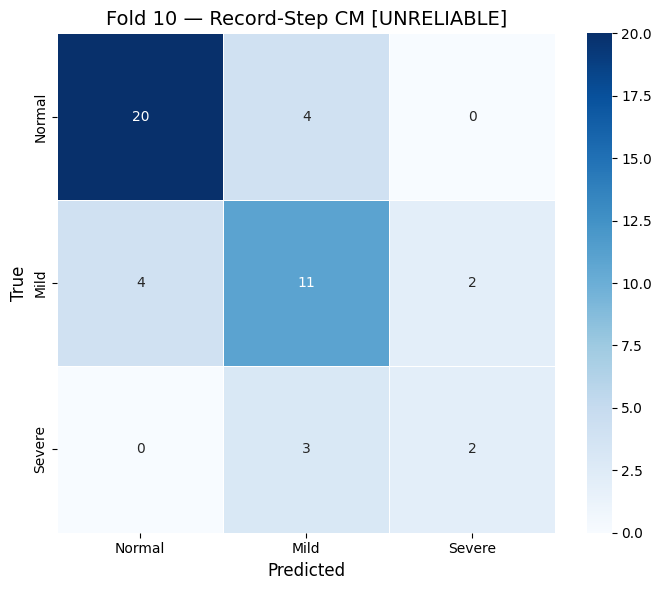


CROSS-VALIDATION SUMMARY (Record-Step)
  Reliable folds: 1 / 10 (threshold: 10 Severe step-units)

  -- All 10 folds --
  accuracy              : 0.6699 +/- 0.0475
  balanced_accuracy     : 0.6600 +/- 0.0860
  macro_f1              : 0.6382 +/- 0.0847
  --------------------------------------------------
  precision_Normal  : 0.7287 +/- 0.1041
  recall_Normal  : 0.6544 +/- 0.1143
  f1_Normal  : 0.6801 +/- 0.0705
  precision_Mild    : 0.6657 +/- 0.1232
  recall_Mild    : 0.7039 +/- 0.1004
  f1_Mild    : 0.6730 +/- 0.0649
  precision_Severe  : 0.5312 +/- 0.2089
  recall_Severe  : 0.6218 +/- 0.2724
  f1_Severe  : 0.5615 +/- 0.2186

Overall Confusion Matrix (all folds combined):
[[122  60   6]
 [ 38 149  25]
 [  6  19  41]]

  -- Reliable folds only (1/10) --
  accuracy              : 0.6471 +/- 0.0000
  balanced_accuracy     : 0.6625 +/- 0.0000
  macro_f1              : 0.6457 +/- 0.0000
  --------------------------------------------------
  precision_Normal  : 0.8125 +/- 0.0000
  recall_

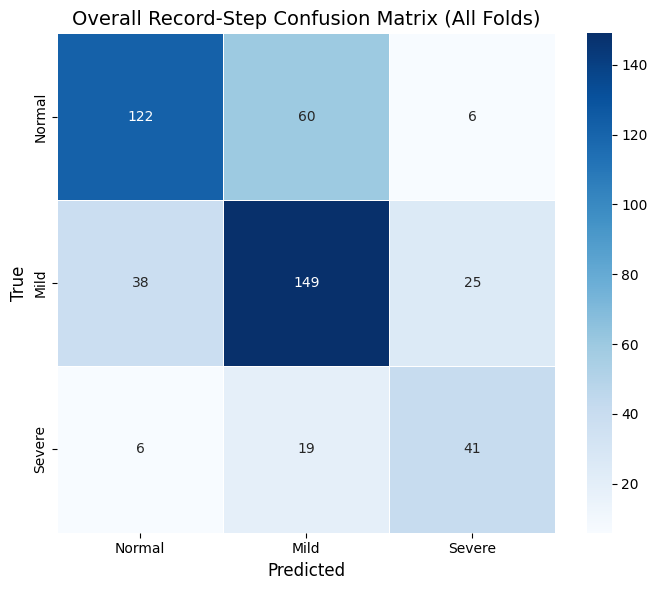

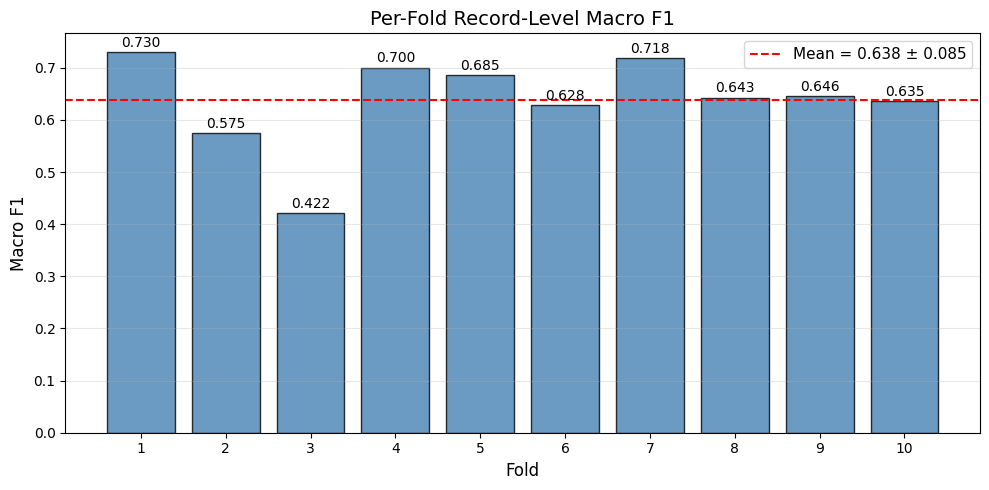


######################################################################
Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}
Mean macro F1: 0.6382
Mean balanced accuracy: 0.6600
Mean Mild recall: 0.7039
Mean Severe recall: 0.6218

Run summary saved to outputs\step23_softmax_short_plan\step23_softmax_results.json


In [13]:
# ═══════════════════════════════════════════════════════════════════
# EXPERIMENT A: STEP 2 + STEP 3 SOFTMAX WITH FIXED CLASS WEIGHTS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "#" * 70)
print("# EXPERIMENT A: Step 2 + Step 3 Softmax Fixed Class Weights")
print("#" * 70)

step_unit_table = build_step_target_table(meta_all)
print(f"\nDataset: {len(X_all)} windows from {len(step_unit_table)} record-steps across {len(np.unique(groups_all))} records")
print(f"Window shape: {X_all.shape}")
if len(meta_all) > 0:
    print(f"Steps: {meta_all['step'].value_counts().sort_index().to_dict()}")
print(f"Classes: {dict(zip(CLASS_NAMES, [int(np.sum(y_all == i)) for i in range(NUM_CLASSES)]))}")
print(f"Engineered features: {CLINICAL_FEATURE_NAMES}")

manual_class_weights = {0: 0.9, 1: 1.2, 2: 2.5}
_original_compute_class_weights_from_y = compute_class_weights_from_y


def _manual_class_weight_resolver_factory(manual_weights):
    def _resolver(y_train: np.ndarray) -> dict:
        if manual_weights is None:
            return _original_compute_class_weights_from_y(y_train)
        resolved = {
            int(cls_idx): float(manual_weights.get(cls_idx, 1.0))
            for cls_idx in range(NUM_CLASSES)
        }
        print(f"  Class weights (manual override): {resolved}")
        return resolved
    return _resolver


try:
    print("\n" + "=" * 70)
    print("Running fixed class-weight experiment")
    print(f"Manual class weights: {manual_class_weights}")
    print("=" * 70)

    compute_class_weights_from_y = _manual_class_weight_resolver_factory(manual_class_weights)
    scratch_results = run_grouped_cv(
        X=X_all,
        y=y_all,
        groups=groups_all,
        metadata=meta_all,
        cfg=CFG,
        mode="scratch",
        X_raw=X_all,
        feature_missing_frac=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
    )
finally:
    compute_class_weights_from_y = _original_compute_class_weights_from_y

scratch_summary = {
    'experiment': 'fixed_class_weights',
    'steps': CFG['step_numbers'],
    'n_folds': CFG['n_splits'],
    'n_reliable_folds': len([r for r in scratch_results if r.get('is_reliable', True)]),
    'window_length': CFG['segment_length'],
    'max_nan_fraction': CFG['max_nan_fraction'],
    'n_windows': len(X_all),
    'n_records': int(len(np.unique(groups_all))),
    'n_record_steps': int(len(step_unit_table)),
    'manual_class_weights': manual_class_weights,
    'mean_macro_f1': float(np.mean([r['macro_f1'] for r in scratch_results])),
    'std_macro_f1': float(np.std([r['macro_f1'] for r in scratch_results])),
    'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in scratch_results])),
    'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in scratch_results])),
    'mean_accuracy': float(np.mean([r['accuracy'] for r in scratch_results])),
    'std_accuracy': float(np.std([r['accuracy'] for r in scratch_results])),
    'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in scratch_results])),
    'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in scratch_results])),
    'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in scratch_results])),
    'per_fold': [
        {k: v for k, v in r.items() if k != 'confusion_matrix'}
        for r in scratch_results
    ],
}

reliable_results = [r for r in scratch_results if r.get('is_reliable', True)]
if reliable_results:
    scratch_summary['reliable_mean_macro_f1'] = float(np.mean([r['macro_f1'] for r in reliable_results]))
    scratch_summary['reliable_std_macro_f1'] = float(np.std([r['macro_f1'] for r in reliable_results]))
    scratch_summary['reliable_mean_balanced_acc'] = float(np.mean([r['balanced_accuracy'] for r in reliable_results]))
    scratch_summary['reliable_std_balanced_acc'] = float(np.std([r['balanced_accuracy'] for r in reliable_results]))

with open(OUTPUT_DIR / "step23_softmax_results.json", 'w') as f:
    json.dump(scratch_summary, f, indent=2, default=str)

print("\n" + "#" * 70)
print(f"Manual weights: {manual_class_weights}")
print(f"Mean macro F1: {scratch_summary['mean_macro_f1']:.4f}")
print(f"Mean balanced accuracy: {scratch_summary['mean_balanced_acc']:.4f}")
print(f"Mean Mild recall: {scratch_summary['mean_recall_Mild']:.4f}")
print(f"Mean Severe recall: {scratch_summary['mean_recall_Severe']:.4f}")
print(f"\nRun summary saved to {OUTPUT_DIR / 'step23_softmax_results.json'}")

In [14]:
# ═══════════════════════════════════════════════════════════════════

# LEGACY TRANSFER CELL (INTENTIONALLY DISABLED IN THE SHORT PLAN)

# ═══════════════════════════════════════════════════════════════════



print("Transfer-learning stages are intentionally disabled in this short Step 2+3 experiment plan.")

print("This notebook now focuses on the standard 3-class softmax baseline with engineered features.")

print("If needed later, the legacy PTB-XL utilities remain above for separate experiments.")


Transfer-learning stages are intentionally disabled in this short Step 2+3 experiment plan.
This notebook now focuses on the standard 3-class softmax baseline with engineered features.
If needed later, the legacy PTB-XL utilities remain above for separate experiments.


In [15]:
# ═══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════


def _fmt(vals):
    return f"{np.mean(vals):.4f} +/- {np.std(vals):.4f}"


print("\n" + "=" * 75)
print("FINAL SUMMARY — STEP 2 + STEP 3 SOFTMAX FIXED CLASS WEIGHTS")
print("=" * 75)

if 'scratch_results' not in globals() or 'scratch_summary' not in globals():
    raise RuntimeError("Run Cell 25 first to execute the fixed class-weight experiment.")

print(f"\nExperiment: {scratch_summary['experiment']}")
print(f"Manual weights: {scratch_summary.get('manual_class_weights')}")

print(f"\nExperiment scope:")
print(f"  Steps used:           {CFG['step_numbers']}")
print(f"  Window length:        {CFG['segment_length']} samples ({CFG['segment_minutes']} min)")
print(f"  Max NaN fraction:     {CFG['max_nan_fraction']:.0%}")
print(f"  Grouped CV by rec_id: yes")
print(f"  Evaluation unit:      record-step")
print(f"  Feature branch:       compact engineered FHR features")

print(f"\nPer-fold reliability (min Severe step-units = {CFG['min_severe_records']}):")
print(f"  {'Fold':<8} {'Macro F1':>12} {'Reliable?':>12}  {'Severe step-units':>18}")
print("  " + "-" * 60)
for i in range(CFG['n_splits']):
    fold = scratch_results[i]
    rel = "Yes" if fold.get('is_reliable', True) else "No"
    sev_n = fold.get('n_severe_val_step_units', '?')
    print(f"  Fold {i + 1:<3} {fold['macro_f1']:>12.4f} {rel:>12}  {sev_n:>18}")

print(f"\nRecord-step metrics across all folds:")
for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
    vals = [r[metric_name] for r in scratch_results]
    print(f"  {metric_name:<22} {_fmt(vals)}")

print("\nPer-class recall:")
for name in CLASS_NAMES:
    vals = [r[f'recall_{name}'] for r in scratch_results]
    print(f"  {name:<22} {_fmt(vals)}")

print("\nPer-class F1:")
for name in CLASS_NAMES:
    vals = [r[f'f1_{name}'] for r in scratch_results]
    print(f"  {name:<22} {_fmt(vals)}")

reliable_s = [r for r in scratch_results if r.get('is_reliable', True)]
if 0 < len(reliable_s) < CFG['n_splits']:
    print(f"\nReliable folds only ({len(reliable_s)}/{CFG['n_splits']}):")
    for metric_name in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        vals = [r[metric_name] for r in reliable_s]
        print(f"  {metric_name:<22} {_fmt(vals)}")
elif len(reliable_s) == CFG['n_splits']:
    print("\nAll folds met the validation reliability threshold.")

print("=" * 75)
print("Results saved to", OUTPUT_DIR)


FINAL SUMMARY — STEP 2 + STEP 3 SOFTMAX FIXED CLASS WEIGHTS

Experiment: fixed_class_weights
Manual weights: {0: 0.9, 1: 1.2, 2: 2.5}

Experiment scope:
  Steps used:           [2, 3]
  Window length:        1800 samples (30 min)
  Max NaN fraction:     16%
  Grouped CV by rec_id: yes
  Evaluation unit:      record-step
  Feature branch:       compact engineered FHR features

Per-fold reliability (min Severe step-units = 10):
  Fold         Macro F1    Reliable?   Severe step-units
  ------------------------------------------------------------
  Fold 1         0.7295           No                   7
  Fold 2         0.5754           No                   7
  Fold 3         0.4218           No                   7
  Fold 4         0.7002           No                   8
  Fold 5         0.6852           No                   5
  Fold 6         0.6285           No                   6
  Fold 7         0.7178           No                   5
  Fold 8         0.6427           No              